<a href="https://colab.research.google.com/github/aashutosh-ks/ALML-Lab-500122809/blob/main/PVR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Experiment No 1: - Installing Anaconda and setup the environment, installation of supporting packages, Linear Regression

## **Installation of Anaconda and Environment Setup**
**Part 1: Installing Anaconda on Windows**

1. To install Anaconda on my Windows system, I first opened a web browser and searched for Anaconda Python. After that, I visited the official website, anaconda.com, and downloaded the Windows installer file (.exe).

2. Once the download was complete, I opened the Downloads folder and ran the installer by double-clicking on it. The setup wizard appeared on the screen, where I clicked Next and accepted the license agreement by selecting I Agree.

3. Next, I chose the installation type as All Users and continued with the default installation directory. In the advanced installation options, I kept the option Register Anaconda3 as my default Python selected, while leaving Add Anaconda to my PATH environment variable unchecked because it is generally not recommended.

4. After reviewing the settings, I clicked Install and waited for the installation process to finish. Finally, I clicked Finish after unchecking the tutorial and additional options.

**Part 2: Environment Setup**

1. After installing Anaconda, I opened the Start Menu and navigated to the Anaconda3 folder. From there, I launched the Anaconda Prompt, which provides a command-line environment for Python and Conda operations.

2. To confirm that Python was installed correctly, I entered the following command:
    python --version
    This displayed the installed Python version.

3. Next, I verified the Conda package manager using:
    conda info
4. To work with notebooks, I started Jupyter Notebook by typing:
    jupyter notebook
    This automatically opened Jupyter Notebook in my default web browser.

5. I also launched the Spyder IDE using the command:
    start spyder
6. In addition, I explored Anaconda Navigator, which can be opened directly from the Start Menu. It provides a graphical interface to launch applications such as Jupyter Notebook, Spyder, and other development tools without using commands.

**Part 3: Installing Supporting Packages**

1. To install additional Python libraries, I reopened the Anaconda Prompt. Using Conda, I installed packages through the following command format:
    conda install package_name
    For example, to install the NumPy library, I used: conda install numpy

2. After entering the command, I followed the instructions displayed on the screen, and the package was installed successfully. This method can also be used to install many other Python libraries required for data science and machine learning projects.

## Linear Regression from Scratch

In [ ]:
# Import libraies

# numpy is used for all numerical and array operations
import numpy as np

# matplotlib is used to plot graphs and visualize data
import matplotlib.pyplot as plt

# these allow us to show live animated plots inside Colab/Jupyter
from IPython.display import display, clear_output

# time module is used to add small delays between animation frames
import time

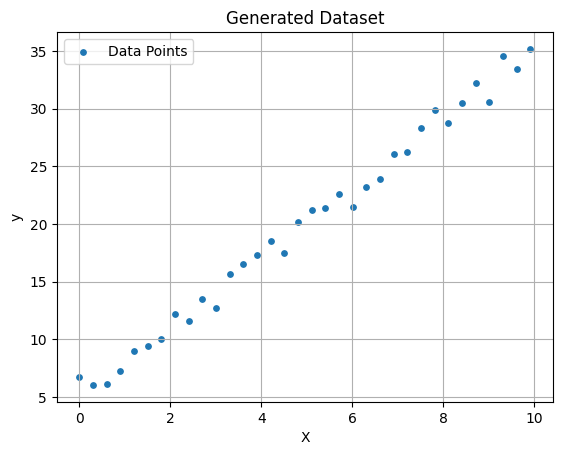

In [ ]:
# Gernate Synthetic Dataset

# fix random seed so we get same data every run
np.random.seed(0)

# create 1000 evenly spaced x values between 0 and 10
X = np.linspace(0, 10, 1000)

# these are the TRUE parameters we want the model to learn
true_b = 5   # true intercept
true_w = 3   # true slope

# add random noise to simulate real-world data (mean=0, std=1)
noise = np.random.normal(0, 1, 1000)

# generate target values: y = 5 + 3x + noise
y = true_b + true_w * X + noise

# m = number of training examples
m = len(X)

# visualize the dataset
plt.scatter(X[::30], y[::30], s=15, label='Data Points')
plt.xlabel('X')
plt.ylabel('y')
plt.title('Generated Dataset')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Initialize Parameters and Run Gradient Descent

# start with weight = 0 (model knows nothing)
w = 0

# start with bias = 0
b = 0

# learning rate: controls how large each update step is
alpha = 0.02

# number of training iterations
epochs = 300

# list to store cost at each epoch for plotting
cost_history = []

# ---- Gradient Descent Loop ----
for epoch in range(epochs):

    # compute predictions using current w and b
    f = b + w * X

    # compute MSE cost (how wrong are our predictions)
    J = (1 / (2 * m)) * np.sum((f - y) ** 2)
    cost_history.append(J)

    # compute gradients (direction to move w and b)
    deltaJ_w = (1 / m) * np.sum((f - y) * X)
    deltaJ_b = (1 / m) * np.sum(f - y)

    # update parameters using gradient descent rule
    w = w - alpha * deltaJ_w
    b = b - alpha * deltaJ_b

print(f"Learned weight w = {w:.4f}  (true value = 3)")
print(f"Learned bias  b = {b:.4f}  (true value = 5)")

Learned weight w = 3.1509  (true value = 3)
Learned bias  b = 3.9526  (true value = 5)


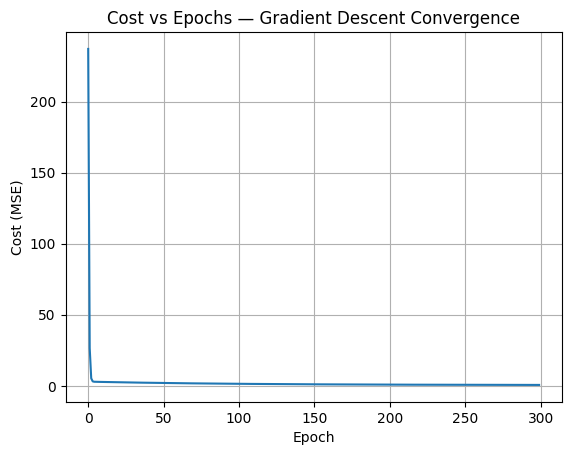

In [ ]:
# Plot Cost vs Epochs

# plot how the cost decreases over training epochs
plt.plot(cost_history)
plt.xlabel('Epoch')
plt.ylabel('Cost (MSE)')
plt.title('Cost vs Epochs — Gradient Descent Convergence')
plt.grid(True)
plt.show()

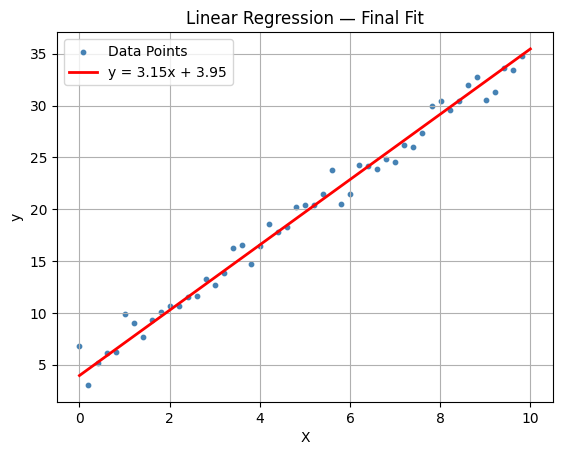

In [ ]:
# Plot Regression Line

# compute final predictions with learned w and b
y_pred = b + w * X

# scatter plot of original data
plt.scatter(X[::20], y[::20], s=10, label='Data Points', color='steelblue')

# plot the learned regression line
plt.plot(X, y_pred, color='red', linewidth=2, label=f'y = {w:.2f}x + {b:.2f}')

plt.xlabel('X')
plt.ylabel('y')
plt.title('Linear Regression — Final Fit')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Compute MSE AND MAE

# Mean Squared Error: average of squared differences
mse = np.mean((y_pred - y) ** 2)

# Mean Absolute Error: average of absolute differences
mae = np.mean(np.abs(y_pred - y))

print(f"Mean Squared Error  (MSE) = {mse:.4f}")
print(f"Mean Absolute Error (MAE) = {mae:.4f}")

Mean Squared Error  (MSE) = 1.2304
Mean Absolute Error (MAE) = 0.8789


In [ ]:
# normalize X for stable gradient descent in animation
X_small = np.array([1, 2, 3, 4, 5, 6])
y_small = np.array([4, 5.2, 8.1, 13.2, 15.8, 17.2])

# z-score normalization
Xn = (X_small - X_small.mean()) / X_small.std()

w2, b2 = 0.0, 0.0
alpha2 = 0.1
n = len(Xn)

for epoch in range(30):
    y_pred2 = w2 * Xn + b2
    error = y_small - y_pred2

    # gradients
    dw = (-2 / n) * np.sum(Xn * error)
    db = (-2 / n) * np.sum(error)

    # update
    w2 -= alpha2 * dw
    b2 -= alpha2 * db

    # live plot
    plt.figure(figsize=(6, 4))
    plt.scatter(X_small, y_small, color='blue', label='Data')
    plt.plot(X_small, w2 * Xn + b2, color='red', label='Fit')
    plt.title(f'Epoch {epoch + 1}')
    plt.xlabel('X')
    plt.ylabel('y')
    plt.legend()
    plt.grid(True)
    display(plt.gcf())
    clear_output(wait=True)
    time.sleep(0.5)
    plt.close()

print('Animation Complete!')

Animation Complete!



=== Experiment 1: Linear Regression using SKLEARN ===
MSE = 0.9817  |  R² = 0.9868


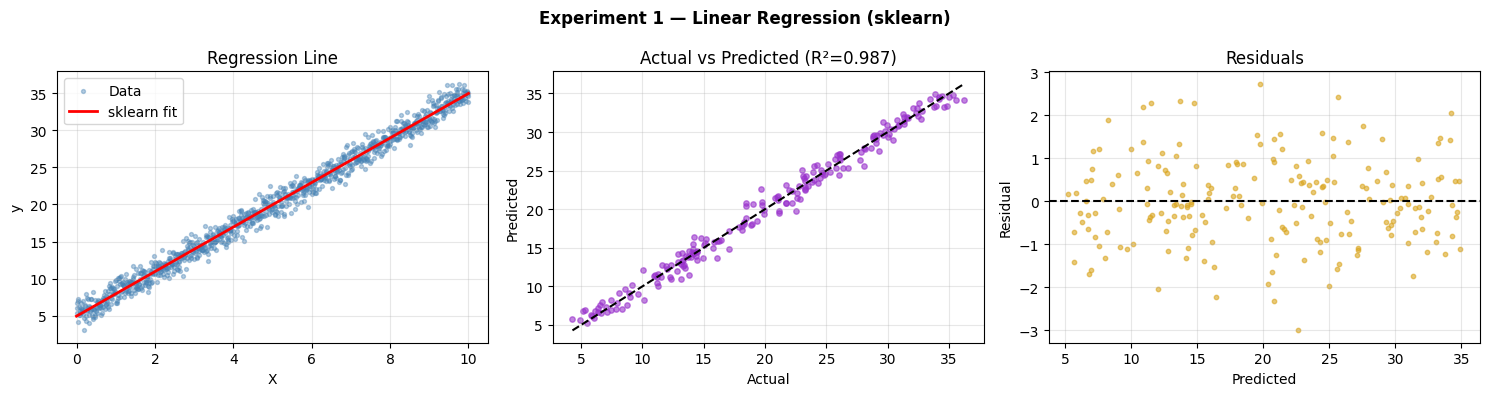

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

print("\n=== Experiment 1: Linear Regression using SKLEARN ===")

X_2d = X.reshape(-1, 1)                                  # sklearn needs 2D input
X_train, X_test, y_train, y_test = train_test_split(
    X_2d, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
Xn_train = scaler.fit_transform(X_train)
Xn_test  = scaler.transform(X_test)

model = LinearRegression()
model.fit(Xn_train, y_train)
y_pred = model.predict(Xn_test)

mse_lib = mean_squared_error(y_test, y_pred)
r2_lib  = r2_score(y_test, y_pred)
print(f"MSE = {mse_lib:.4f}  |  R² = {r2_lib:.4f}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Experiment 1 — Linear Regression (sklearn)", fontweight='bold')

axes[0].scatter(X, y, s=8, alpha=0.4, color='steelblue', label='Data')
axes[0].plot(X_2d, model.predict(scaler.transform(X_2d)),
             color='red', lw=2, label='sklearn fit')
axes[0].set(title='Regression Line', xlabel='X', ylabel='y')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].scatter(y_test, y_pred, s=15, color='darkorchid', alpha=0.6)
lim = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
axes[1].plot(lim, lim, 'k--', lw=1.5)
axes[1].set(title=f'Actual vs Predicted (R²={r2_lib:.3f})', xlabel='Actual', ylabel='Predicted')
axes[1].grid(True, alpha=0.3)

resid = y_test - y_pred
axes[2].scatter(y_pred, resid, s=10, color='goldenrod', alpha=0.6)
axes[2].axhline(0, color='black', lw=1.5, linestyle='--')
axes[2].set(title='Residuals', xlabel='Predicted', ylabel='Residual')
axes[2].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

# Experiment No 2: - Linear Regression and Non-Linear Regression, Linear and Non Linear Curve fitting for regression type of problem, Error correction methods, MSE and MAE

## **Part A: Linear vs Non-Linear Curve Fitting from Scratch**

In [ ]:
# import required libraries
import numpy as np
import matplotlib.pyplot as plt

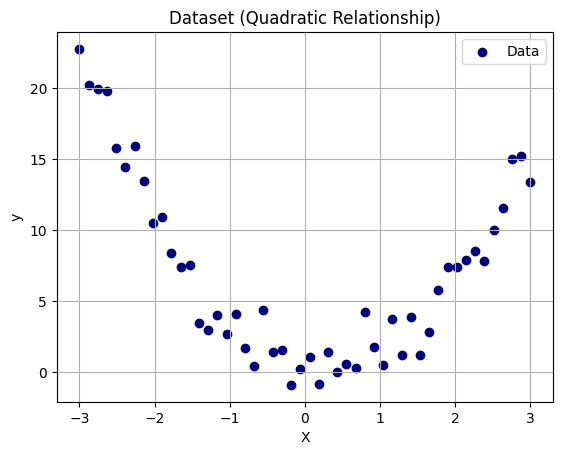

In [ ]:
# ---- generate a non-linear dataset (quadratic relationship) ----
np.random.seed(42)

# 50 x values between -3 and 3
X = np.linspace(-3, 3, 50)

# true relationship is quadratic: y = 2x^2 - x + 1 + noise
y = 2 * X**2 - X + 1 + np.random.normal(0, 1.5, 50)

plt.scatter(X, y, color='navy', label='Data')
plt.title('Dataset (Quadratic Relationship)')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# ---- Linear Regression on non-linear data ----

# build feature matrix: just [1, x] for linear model
X_linear = np.c_[np.ones(len(X)), X]

# solve using Normal Equation: w = (X^T X)^-1 X^T y
# this gives the exact optimal weights without gradient descent
w_linear = np.linalg.pinv(X_linear.T @ X_linear) @ X_linear.T @ y

# predictions from linear model
y_linear = X_linear @ w_linear

# MSE and MAE for linear fit
mse_linear = np.mean((y_linear - y)**2)
mae_linear = np.mean(np.abs(y_linear - y))

print(f"Linear Model — MSE: {mse_linear:.4f} | MAE: {mae_linear:.4f}")

Linear Model — MSE: 35.7987 | MAE: 5.2237


In [ ]:
# ---- Non-Linear Regression (Polynomial degree 2) ----

# build feature matrix: [1, x, x^2]
# this allows the model to fit a curved line
X_poly = np.c_[np.ones(len(X)), X, X**2]

# solve using Normal Equation
w_poly = np.linalg.pinv(X_poly.T @ X_poly) @ X_poly.T @ y

# predictions from polynomial model
y_poly = X_poly @ w_poly

# MSE and MAE for polynomial fit
mse_poly = np.mean((y_poly - y)**2)
mae_poly = np.mean(np.abs(y_poly - y))

print(f"Polynomial Model — MSE: {mse_poly:.4f} | MAE: {mae_poly:.4f}")

Polynomial Model — MSE: 1.7945 | MAE: 1.0923


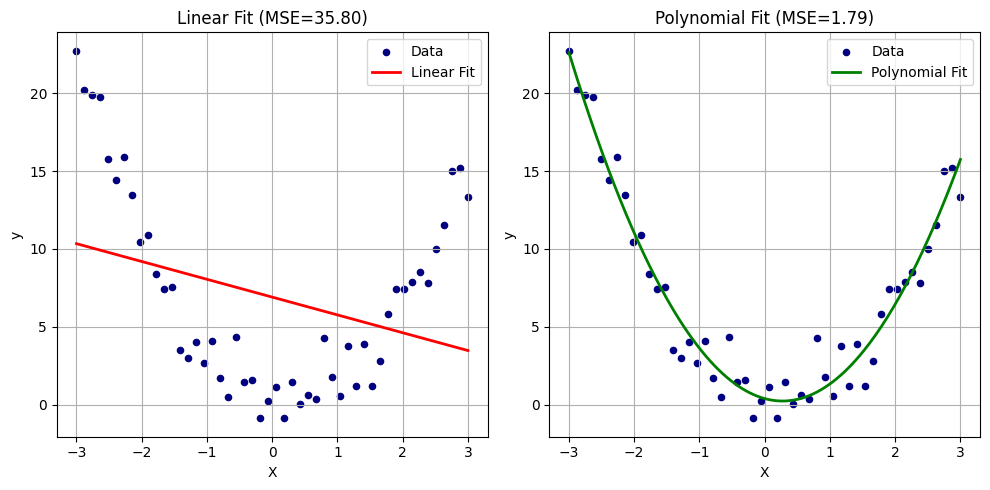

Polynomial fit is better because the data has a curved pattern.


In [ ]:
# ---- Compare Linear vs Polynomial fit ----
X_plot = np.linspace(-3, 3, 200)

# linear predictions on dense x range
y_plot_linear = w_linear[0] + w_linear[1] * X_plot

# polynomial predictions on dense x range
y_plot_poly = w_poly[0] + w_poly[1] * X_plot + w_poly[2] * X_plot**2

plt.figure(figsize=(10, 5))

# left: linear fit
plt.subplot(1, 2, 1)
plt.scatter(X, y, color='navy', s=20, label='Data')
plt.plot(X_plot, y_plot_linear, color='red', linewidth=2, label='Linear Fit')
plt.title(f'Linear Fit (MSE={mse_linear:.2f})')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.grid(True)

# right: polynomial fit
plt.subplot(1, 2, 2)
plt.scatter(X, y, color='navy', s=20, label='Data')
plt.plot(X_plot, y_plot_poly, color='green', linewidth=2, label='Polynomial Fit')
plt.title(f'Polynomial Fit (MSE={mse_poly:.2f})')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()
print('Polynomial fit is better because the data has a curved pattern.')

## Part A: Curve Fitting using LIBRARIES


=== Experiment 2: Curve Fitting using SKLEARN ===
Linear  Model — MSE: 35.7987
Polynomial (d=2) — MSE: 1.7945


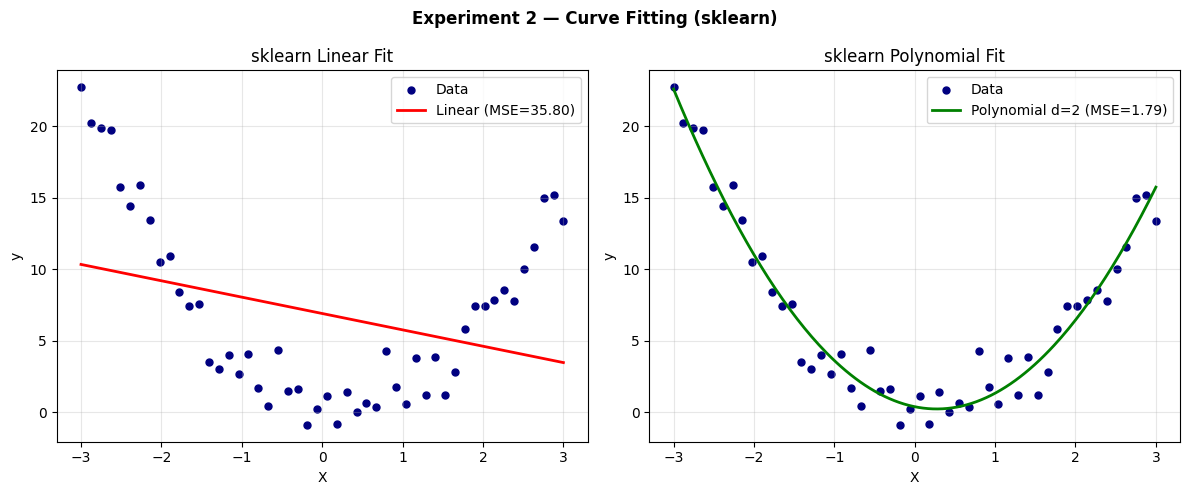

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error

print("\n=== Experiment 2: Curve Fitting using SKLEARN ===")

X_2d = X.reshape(-1, 1)

# Pipeline chains multiple steps into one object
# Step 1: transform input, Step 2: fit the model
# This ensures the same transformation is applied consistently

# Linear pipeline
lin_pipe = Pipeline([('model', LinearRegression())])
lin_pipe.fit(X_2d, y)
y_lin_lib = lin_pipe.predict(X_2d)
mse_lin_lib = mean_squared_error(y, y_lin_lib)

# Polynomial degree 2 pipeline
# PolynomialFeatures(degree=2): converts [x] into [1, x, x²]
# This allows the linear model to fit a curved (parabolic) line
# include_bias=True: automatically adds the constant term (intercept)

# Polynomial degree 2 pipeline
poly_pipe = Pipeline([
    ('poly', PolynomialFeatures(degree=2, include_bias=True)),
    ('model', LinearRegression())
])
poly_pipe.fit(X_2d, y)
y_poly_lib = poly_pipe.predict(X_2d)
mse_poly_lib = mean_squared_error(y, y_poly_lib)

print(f"Linear  Model — MSE: {mse_lin_lib:.4f}")
print(f"Polynomial (d=2) — MSE: {mse_poly_lib:.4f}")

X_plot_2d = np.linspace(-3, 3, 200).reshape(-1, 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Experiment 2 — Curve Fitting (sklearn)", fontweight='bold')

axes[0].scatter(X, y, color='navy', s=25, label='Data')
axes[0].plot(X_plot_2d, lin_pipe.predict(X_plot_2d), 'red', lw=2,
             label=f'Linear (MSE={mse_lin_lib:.2f})')
axes[0].set(title='sklearn Linear Fit', xlabel='X', ylabel='y')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].scatter(X, y, color='navy', s=25, label='Data')
axes[1].plot(X_plot_2d, poly_pipe.predict(X_plot_2d), 'green', lw=2,
             label=f'Polynomial d=2 (MSE={mse_poly_lib:.2f})')
axes[1].set(title='sklearn Polynomial Fit', xlabel='X', ylabel='y')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Part B: Multi-Variable Linear Regression on California Housing Dataset

In [ ]:
# load the California Housing dataset directly from GitHub (no Kaggle needed)
import pandas as pd

url = "https://raw.githubusercontent.com/ageron/handson-ml/master/datasets/housing/housing.csv"
df = pd.read_csv(url)

print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Dataset Shape: (20640, 10)

First 5 rows:


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [ ]:
# ---- Preprocessing ----

# keep only numeric columns (drop 'ocean_proximity' text column)
df_num = df.select_dtypes(include=[np.number])

# fill missing values with column mean
df_num = df_num.fillna(df_num.mean())

# separate features (X) and target (y)
y_house = df_num['median_house_value'].values
X_house = df_num.drop('median_house_value', axis=1).values

print("Features shape:", X_house.shape)
print("Target shape:", y_house.shape)

Features shape: (20640, 8)
Target shape: (20640,)


In [ ]:
# ---- Normalize features and target ----

# z-score normalize the target (helps gradient descent)
y_house = (y_house - y_house.mean()) / y_house.std()

# normalize features using max-abs scaling
def max_abs_norm(X):
    # find the max absolute value in each column
    maxv = np.max(np.abs(X), axis=0)
    # replace zeros to avoid division by zero
    maxv[maxv == 0] = 1
    return X / maxv

X_house = max_abs_norm(X_house)

# add a column of ones for the bias term
m_h = X_house.shape[0]
X_house = np.c_[np.ones(m_h), X_house]

print("X shape after adding bias column:", X_house.shape)

X shape after adding bias column: (20640, 9)


In [ ]:
# ---- Define hypothesis and cost functions ----

def predict(X, w):
    # matrix multiplication gives predictions for all examples at once
    return X @ w

def compute_mse(X, y, w):
    # mean squared error
    m = len(y)
    return (1 / (2 * m)) * np.sum((predict(X, w) - y) ** 2)

def compute_mae(X, y, w):
    # mean absolute error
    return np.mean(np.abs(predict(X, w) - y))

In [ ]:
# ---- Gradient Descent ----

# initialize all weights to zero
w_h = np.zeros(X_house.shape[1])

alpha_h = 0.1      # learning rate
epochs_h = 1000    # number of iterations
m_h = len(y_house)
costs_h = []

for i in range(epochs_h):
    # compute predictions
    preds = predict(X_house, w_h)

    # compute gradient vector (one gradient per weight)
    gradient = (1 / m_h) * (X_house.T @ (preds - y_house))

    # update all weights simultaneously
    w_h = w_h - alpha_h * gradient

    # record cost every epoch
    costs_h.append(compute_mse(X_house, y_house, w_h))

print("Training complete!")
print(f"Final MSE  = {compute_mse(X_house, y_house, w_h):.6f}")
print(f"Final MAE  = {compute_mae(X_house, y_house, w_h):.6f}")

Training complete!
Final MSE  = 0.250200
Final MAE  = 0.539923


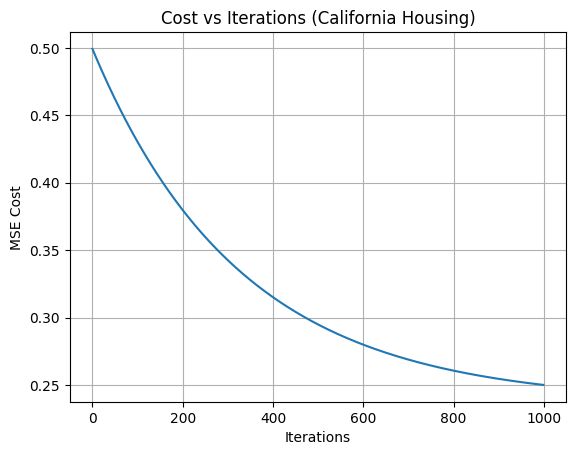

In [ ]:
# ---- Plot cost convergence ----
plt.plot(costs_h)
plt.xlabel('Iterations')
plt.ylabel('MSE Cost')
plt.title('Cost vs Iterations (California Housing)')
plt.grid(True)
plt.show()

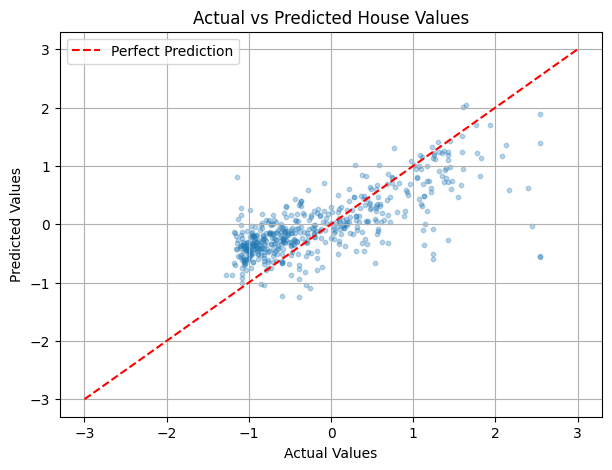

In [ ]:
# ---- Plot predicted vs actual ----
y_final_pred = predict(X_house, w_h)

plt.figure(figsize=(7, 5))
plt.scatter(y_house[:500], y_final_pred[:500], alpha=0.3, s=10)
plt.plot([-3, 3], [-3, 3], 'r--', label='Perfect Prediction')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs Predicted House Values')
plt.legend()
plt.grid(True)
plt.show()

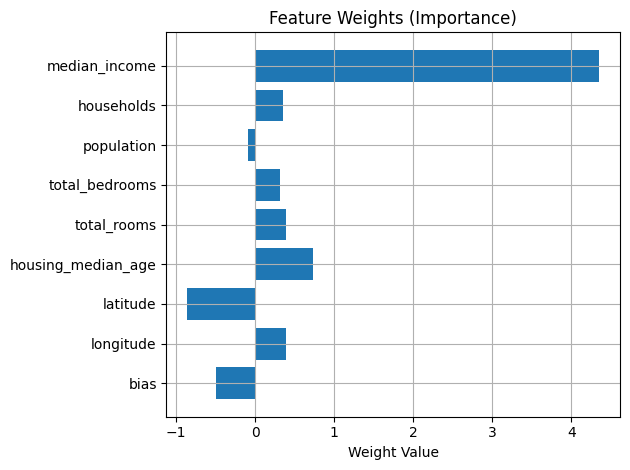

In [ ]:
# ---- Feature importance (learned weights) ----
feature_names = ['bias'] + list(df_num.drop('median_house_value', axis=1).columns)

plt.barh(feature_names, w_h)
plt.xlabel('Weight Value')
plt.title('Feature Weights (Importance)')
plt.grid(True)
plt.tight_layout()
plt.show()

# Experiment No 3: -Logistic Regression and Sigmoid function for classification based problem.TPR, FPR, TNR, FNR, Recall, Precision, Sensitivity, ROC-AUC curve analysis.

In [ ]:
# 1. Dataset
import numpy as np

# set random seed so results are same every time we run
np.random.seed(42)

# simple dataset (binary classification)
# create 100 evenly spaced values between 0 and 10
X = np.linspace(0, 10, 100)

# create labels: 0 if x < 5 (class 0), 1 if x >= 5 (class 1)
y = np.array([0 if i < 5 else 1 for i in X])

# initialization
# w = weight starts at 0 (model has no knowledge yet)
w = 0
# b = bias starts at 0
b = 0
# alpha = learning rate, how big each update step is
alpha = 0.1
# epochs = how many times we go through the full dataset
epochs = 200
# m = total number of training examples
m = len(X)

# sigmoid function
# squashes any number into a probability between 0 and 1
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# list to store cost at each epoch for later plotting
cost_history = []

# training loop
for epoch in range(epochs):

    # compute z = b + w*x (linear combination)
    z = b + w * X
    # apply sigmoid to get predicted probability
    y_predicted = sigmoid(z)

    # gradients
    # dJ/dw tells us which direction to change w
    delta_J_w = (1/m) * np.sum((y_predicted - y) * X)
    # dJ/db tells us which direction to change b
    delta_J_b = (1/m) * np.sum(y_predicted - y)

    # update w and b using gradient descent rule
    w = w - alpha * delta_J_w
    b = b - alpha * delta_J_b

    # cost (log loss / binary cross-entropy)
    # measures how wrong our predictions are on average
    cost = -(1/m) * np.sum(y*np.log(y_predicted) + (1-y)*np.log(1 - y_predicted))
    cost_history.append(cost)

    # print cost every 50 epochs to monitor progress
    if epoch % 50 == 0:
        print("Epoch", epoch, "Cost:", cost)

print("Final w:", w)
print("Final b:", b)

# prediction: use learned w and b to compute probabilities
y_final = sigmoid(b + w * X)

# converting probability to class label (0 or 1)
# if probability >= 0.5 → predict class 1, else class 0
predictions = [1 if i >= 0.5 else 0 for i in y_final]

print("Predictions:", predictions)

Epoch 0 Cost: 0.6931471805599453
Epoch 50 Cost: 0.456095999749688
Epoch 100 Cost: 0.3736183895293005
Epoch 150 Cost: 0.3213713031006304
Final w: 0.5687659715117851
Final b: -2.351521085257704
Predictions: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]


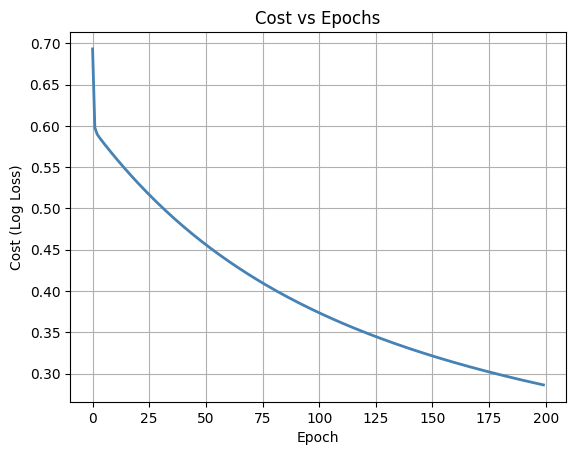

In [ ]:
# 2. Plot cost convergence
import matplotlib.pyplot as plt

# a decreasing curve confirms gradient descent is working
plt.plot(cost_history, color='steelblue', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Cost (Log Loss)')
plt.title('Cost vs Epochs')
plt.grid(True)
plt.show()

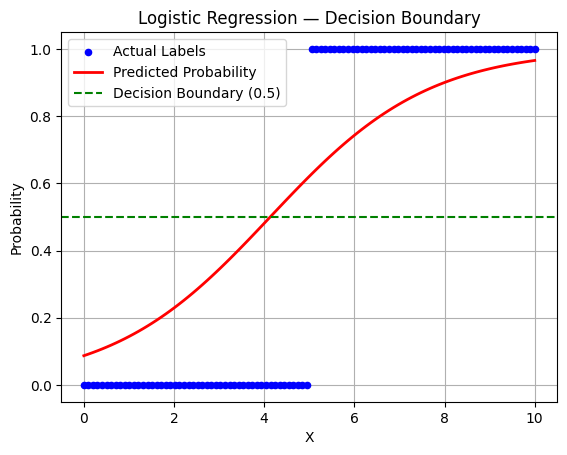

In [ ]:
# 3. Plot sigmoid curve and decision boundary

# plot actual data points
plt.scatter(X, y, color='blue', s=20, label='Actual Labels', zorder=3)

# plot the learned sigmoid probability curve
plt.plot(X, y_final, color='red', linewidth=2, label='Predicted Probability')

# the 0.5 line is the decision boundary
# everything above 0.5 is class 1, below is class 0
plt.axhline(0.5, color='green', linestyle='--', label='Decision Boundary (0.5)')

plt.xlabel('X')
plt.ylabel('Probability')
plt.title('Logistic Regression — Decision Boundary')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# 4. Confusion Matrix and Performance Metrics

predictions = np.array(predictions)

# confusion matrix elements
# TP: predicted 1, actual 1 (correct positive)
TP = np.sum((predictions == 1) & (y == 1))
# TN: predicted 0, actual 0 (correct negative)
TN = np.sum((predictions == 0) & (y == 0))
# FP: predicted 1, actual 0 (wrong — false alarm)
FP = np.sum((predictions == 1) & (y == 0))
# FN: predicted 0, actual 1 (wrong — missed positive)
FN = np.sum((predictions == 0) & (y == 1))

print(f"TP={TP}  TN={TN}  FP={FP}  FN={FN}")

# TPR = True Positive Rate = Recall = Sensitivity
TPR = TP / (TP + FN)
# FPR = False Positive Rate
FPR = FP / (FP + TN)
# TNR = True Negative Rate = Specificity
TNR = TN / (TN + FP)
# FNR = False Negative Rate
FNR = FN / (TP + FN)
# Precision = out of all positive predictions, how many were correct
Precision = TP / (TP + FP)
# Recall = out of all actual positives, how many did we catch
Recall = TPR
# F1 = harmonic mean of Precision and Recall
F1 = 2 * Precision * Recall / (Precision + Recall)
# Accuracy = overall correctness
Accuracy = (TP + TN) / (TP + TN + FP + FN)

print("\n=== Performance Metrics ===")
print(f"  Accuracy  = {Accuracy:.4f}")
print(f"  TPR       = {TPR:.4f}  (Recall / Sensitivity)")
print(f"  FPR       = {FPR:.4f}")
print(f"  TNR       = {TNR:.4f}  (Specificity)")
print(f"  FNR       = {FNR:.4f}")
print(f"  Precision = {Precision:.4f}")
print(f"  Recall    = {Recall:.4f}")
print(f"  F1 Score  = {F1:.4f}")

TP=50  TN=41  FP=9  FN=0

=== Performance Metrics ===
  Accuracy  = 0.9100
  TPR       = 1.0000  (Recall / Sensitivity)
  FPR       = 0.1800
  TNR       = 0.8200  (Specificity)
  FNR       = 0.0000
  Precision = 0.8475
  Recall    = 1.0000
  F1 Score  = 0.9174


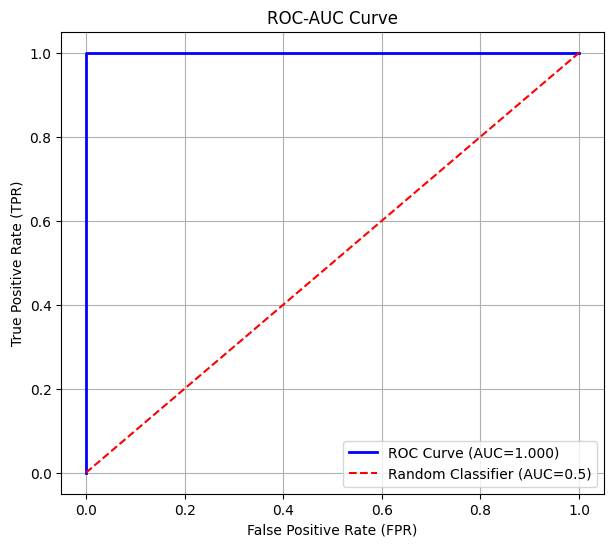

AUC Score = 1.0000


In [ ]:
# 5. ROC Curve and AUC from Scratch

# try 100 different threshold values between 0 and 1
thresholds = np.linspace(0, 1, 100)
TPR_list = []
FPR_list = []

for t in thresholds:
    # at threshold t, convert probabilities to class labels
    y_pred_t = (y_final >= t).astype(int)

    TP_t = np.sum((y_pred_t == 1) & (y == 1))
    TN_t = np.sum((y_pred_t == 0) & (y == 0))
    FP_t = np.sum((y_pred_t == 1) & (y == 0))
    FN_t = np.sum((y_pred_t == 0) & (y == 1))

    # handle edge cases where denominator is 0
    tpr_t = TP_t / (TP_t + FN_t) if (TP_t + FN_t) > 0 else 0
    fpr_t = FP_t / (FP_t + TN_t) if (FP_t + TN_t) > 0 else 0

    TPR_list.append(tpr_t)
    FPR_list.append(fpr_t)

# AUC using trapezoidal rule
# area under the ROC curve — closer to 1.0 is better
auc = 0
for i in range(1, len(FPR_list)):
    auc += abs((FPR_list[i] - FPR_list[i-1]) * (TPR_list[i] + TPR_list[i-1]) / 2)

# plot ROC curve
plt.figure(figsize=(7, 6))
plt.plot(FPR_list, TPR_list, color='blue', linewidth=2, label=f'ROC Curve (AUC={auc:.3f})')
# diagonal dashed line = random classifier (AUC = 0.5)
plt.plot([0, 1], [0, 1], 'r--', label='Random Classifier (AUC=0.5)')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC-AUC Curve')
plt.legend()
plt.grid(True)
plt.show()

print(f"AUC Score = {auc:.4f}")

### Logistic Regression using LIBRARIES


=== Experiment 3: Logistic Regression using SKLEARN (Diabetes Dataset) ===
  Accuracy = 71.43%  |  AUC = 0.8230
  TPR=0.5185  TNR=0.8200  Precision=0.6087  F1=0.5600


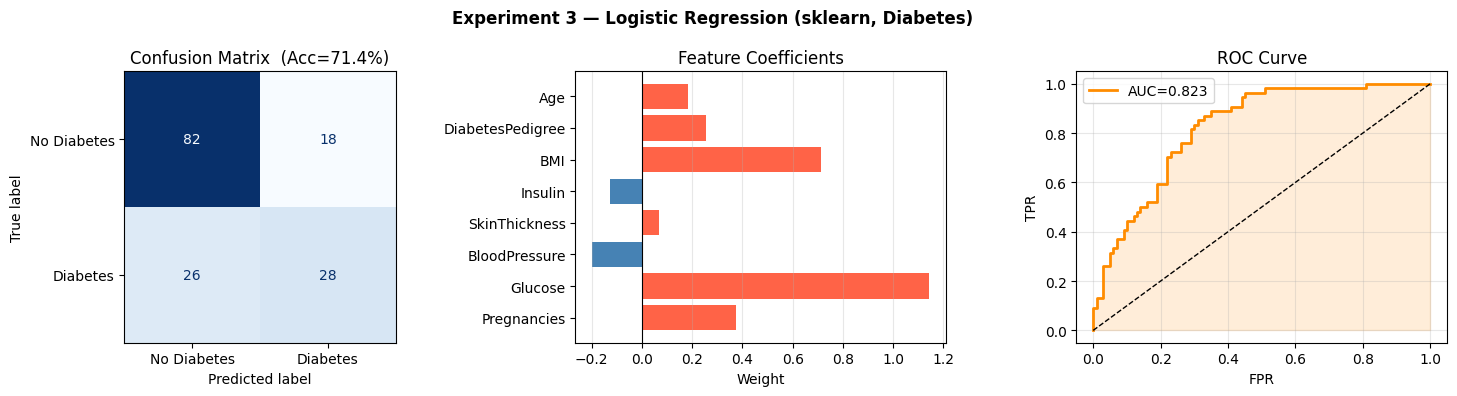

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, confusion_matrix,
                              roc_curve, roc_auc_score, ConfusionMatrixDisplay)
import pandas as pd

print("\n=== Experiment 3: Logistic Regression using SKLEARN (Diabetes Dataset) ===")

url = ("https://raw.githubusercontent.com/jbrownlee/"
       "Datasets/master/pima-indians-diabetes.data.csv")
col_names = ['Pregnancies','Glucose','BloodPressure','SkinThickness',
             'Insulin','BMI','DiabetesPedigree','Age','Outcome']
df = pd.read_csv(url, names=col_names)
X_dia = df.iloc[:, :-1].values
y_dia = df.iloc[:,  -1].values

X_train, X_test, y_train, y_test = train_test_split(
    X_dia, y_dia, test_size=0.2, random_state=42, stratify=y_dia)

scaler = StandardScaler()
Xn_train = scaler.fit_transform(X_train)
Xn_test  = scaler.transform(X_test)

model = LogisticRegression(max_iter=1000, solver='lbfgs', random_state=42)
model.fit(Xn_train, y_train)
y_pred  = model.predict(Xn_test)
y_proba = model.predict_proba(Xn_test)[:, 1]

acc = accuracy_score(y_test, y_pred) * 100
auc = roc_auc_score(y_test, y_proba)
print(f"  Accuracy = {acc:.2f}%  |  AUC = {auc:.4f}")

cm = confusion_matrix(y_test, y_pred)
TN_l, FP_l, FN_l, TP_l = cm.ravel()
TPR_l = TP_l/(TP_l+FN_l); FPR_l = FP_l/(FP_l+TN_l)
TNR_l = TN_l/(TN_l+FP_l); FNR_l = FN_l/(TP_l+FN_l)
Prec_l = TP_l/(TP_l+FP_l); F1_l = 2*Prec_l*TPR_l/(Prec_l+TPR_l)
print(f"  TPR={TPR_l:.4f}  TNR={TNR_l:.4f}  Precision={Prec_l:.4f}  F1={F1_l:.4f}")

fpr_r, tpr_r, _ = roc_curve(y_test, y_proba)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Experiment 3 — Logistic Regression (sklearn, Diabetes)", fontweight='bold')

disp = ConfusionMatrixDisplay(cm, display_labels=["No Diabetes","Diabetes"])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title(f'Confusion Matrix  (Acc={acc:.1f}%)')

axes[1].barh(col_names[:-1], model.coef_[0],
             color=['tomato' if v>0 else 'steelblue' for v in model.coef_[0]])
axes[1].axvline(0, color='black', lw=0.8)
axes[1].set(title='Feature Coefficients', xlabel='Weight')
axes[1].grid(True, alpha=0.3, axis='x')

axes[2].plot(fpr_r, tpr_r, color='darkorange', lw=2, label=f'AUC={auc:.3f}')
axes[2].plot([0,1],[0,1],'k--',lw=1)
axes[2].fill_between(fpr_r, tpr_r, alpha=0.15, color='darkorange')
axes[2].set(title='ROC Curve', xlabel='FPR', ylabel='TPR')
axes[2].legend(); axes[2].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

Experiment No 4: - Un-Supervised Learning, k-Means Clustering & Elbow Rule
Theory:

K-Means is an unsupervised algorithm that groups data into k clusters

Step 1.  (Assignment): Each point is assigned to the nearest centroid

Step 2 (Update): Each centroid is recalculated as the mean of its assigned points

Repeats until convergence

Elbow Rule: Plot WCSS vs k — the 'elbow' point gives optimal k

WCSS = Σ ||x − centroid||² (Within-Cluster Sum of Squares)

### K-Means FROM SCRATCH

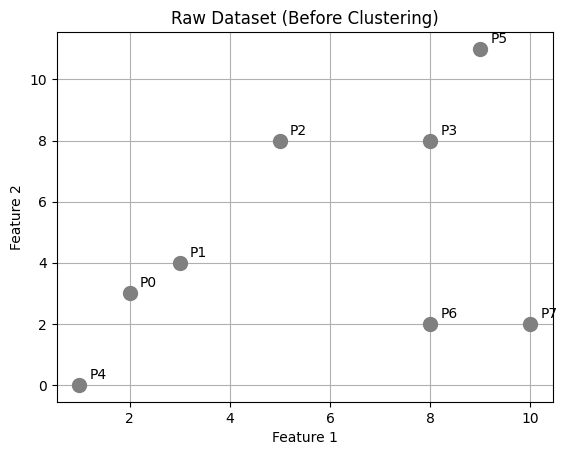

In [ ]:
# import required libraries
import numpy as np
import matplotlib.pyplot as plt

# Sample dataset (same as sir's code)
# each row is one 2D data point (x, y)
data = np.array([
    [2, 3],
    [3, 4],
    [5, 8],
    [8, 8],
    [1, 0],
    [9, 11],
    [8, 2],
    [10, 2]
])

# visualize the raw data before clustering
plt.scatter(data[:, 0], data[:, 1], color='gray', s=100, zorder=3)
# annotate each point with its index
for i, point in enumerate(data):
    plt.annotate(f'P{i}', (point[0]+0.2, point[1]+0.2))
plt.title('Raw Dataset (Before Clustering)')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.grid(True)
plt.show()

In [ ]:
# number of clusters
K = 2

# randomly choose K points as initial centroids
# these are the starting positions of the cluster centers
np.random.seed(42)
centroids = data[np.random.choice(len(data), K, replace=False)]

print("Initial centroids:")
print(centroids)

Initial centroids:
[[ 3  4]
 [ 9 11]]


In [ ]:
# euclidean distance function
# computes the straight-line distance between two points a and b
def euclidean_distance(a, b):
    return np.sqrt(np.sum((a - b) ** 2))

# test the distance function
print("Distance between [2,3] and [5,7]:", euclidean_distance(np.array([2,3]), np.array([5,7])))

Distance between [2,3] and [5,7]: 5.0


In [ ]:
# K-Means algorithm from scratch
def kmeans(data, K, max_iters=100):

    # randomly pick K data points as starting centroids
    centroids = data[np.random.choice(len(data), K, replace=False)]

    for _ in range(max_iters):
        # create K empty lists to hold points for each cluster
        clusters = [[] for _ in range(K)]

        # --- Assignment Step ---
        # assign each data point to the nearest centroid
        for point in data:
            # compute distance from this point to all K centroids
            distances = [euclidean_distance(point, c) for c in centroids]
            # find which centroid is closest
            cluster_index = np.argmin(distances)
            # add this point to that cluster
            clusters[cluster_index].append(point)

        # save old centroids to check convergence later
        old_centroids = centroids.copy()

        # --- Update Step ---
        # recalculate each centroid as the mean of all points in the cluster
        for i in range(K):
            if clusters[i]:  # avoid empty cluster (would cause divide-by-zero)
                centroids[i] = np.mean(clusters[i], axis=0)

        # --- Convergence Check ---
        # if centroids didn't move, we have converged — stop early
        if np.all(old_centroids == centroids):
            break

    return centroids, clusters

In [ ]:
# run K-Means with K=2
centroids, clusters = kmeans(data, K=2)

print("Final Centroids:", centroids)

Final Centroids: [[5 6]
 [6 1]]


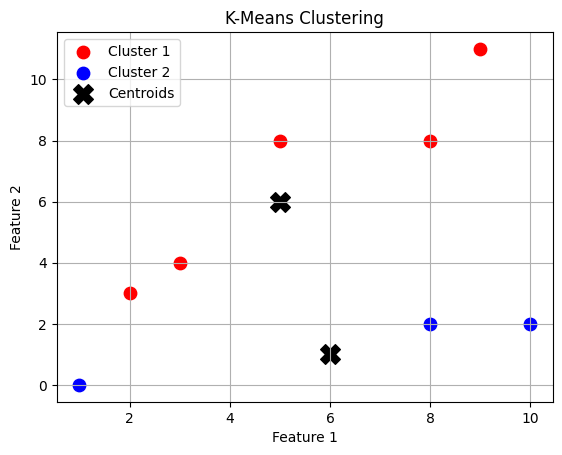

In [ ]:
# plot the clustering result
colors = ['red', 'blue']

for i, cluster in enumerate(clusters):
    # convert cluster list to numpy array for plotting
    cluster = np.array(cluster)
    # scatter plot each cluster with its color
    plt.scatter(cluster[:, 0], cluster[:, 1], c=colors[i], label=f'Cluster {i+1}', s=80)

# plot final centroids as black X markers
plt.scatter(centroids[:, 0], centroids[:, 1], c='black', marker='X', s=200, label='Centroids')

plt.title("K-Means Clustering")
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True)
plt.show()

K=1  WCSS=194.00
K=2  WCSS=90.00
K=3  WCSS=28.00
K=4  WCSS=19.00
K=5  WCSS=9.00
K=6  WCSS=4.00
K=7  WCSS=2.00


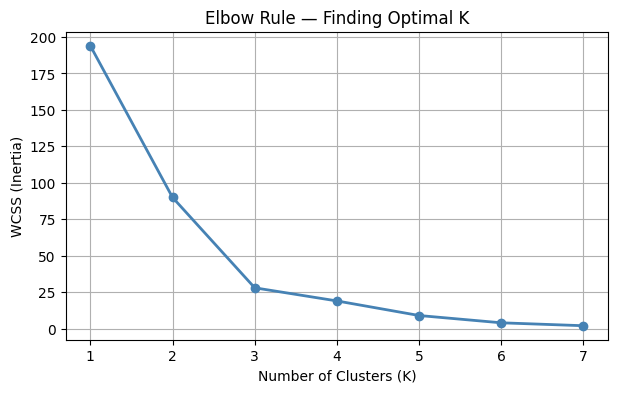


The 'elbow' point in the graph gives the optimal K value.


In [ ]:
# Elbow Rule — find the best value of K

# WCSS = Within-Cluster Sum of Squares
# measures total spread within clusters — lower is better
def compute_wcss(data, K):
    centroids, clusters = kmeans(data, K)
    wcss = 0
    for i in range(K):
        for point in clusters[i]:
            # add squared distance of each point from its centroid
            wcss += euclidean_distance(np.array(point), centroids[i]) ** 2
    return wcss

# try K from 1 to 7
wcss_values = []
K_range = range(1, 8)

for k in K_range:
    wcss = compute_wcss(data, k)
    wcss_values.append(wcss)
    print(f"K={k}  WCSS={wcss:.2f}")

# plot elbow curve
plt.figure(figsize=(7, 4))
plt.plot(list(K_range), wcss_values, marker='o', color='steelblue', linewidth=2)
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS (Inertia)')
plt.title('Elbow Rule — Finding Optimal K')
plt.grid(True)
plt.show()
print("\nThe 'elbow' point in the graph gives the optimal K value.")

### K-Means using LIBRARIES


=== Experiment 4: K-Means using SKLEARN ===
  Silhouette Score (K=2) = 0.4120
  Inertia (WCSS)         = 7.3234


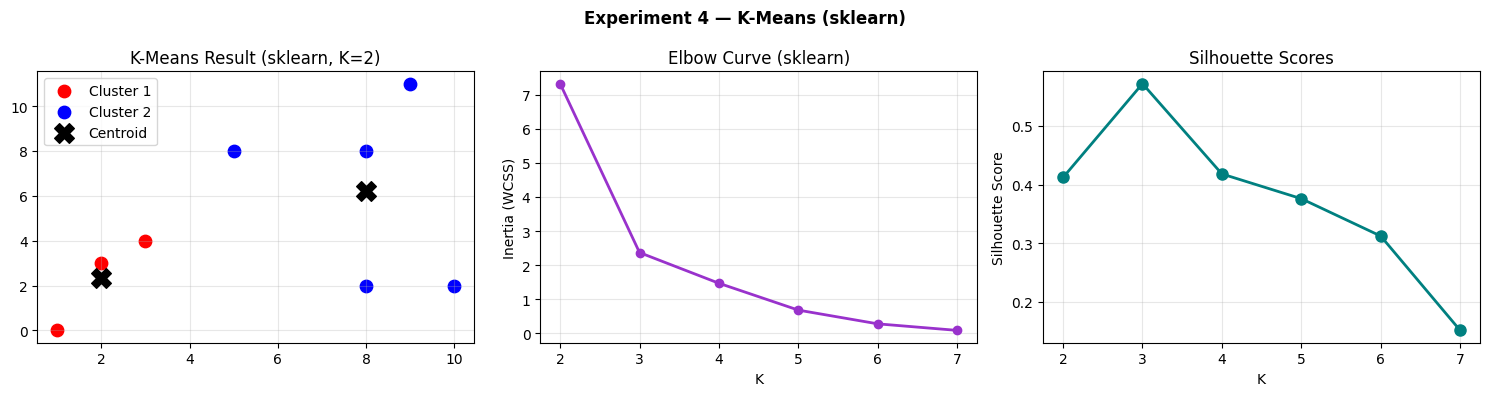

In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

print("\n=== Experiment 4: K-Means using SKLEARN ===")

scaler = StandardScaler()
data_scaled = scaler.fit_transform(data)

# Elbow + Silhouette
wcss_lib, sil_scores = [], []
for k in range(2, 8):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(data_scaled)
    wcss_lib.append(km.inertia_)
    sil_scores.append(silhouette_score(data_scaled, km.labels_))

# Final model K=2
km_final = KMeans(n_clusters=2, random_state=42, n_init=10)
km_final.fit(data_scaled)
labels_lib = km_final.labels_
centroids_lib = scaler.inverse_transform(km_final.cluster_centers_)
sil_final = silhouette_score(data_scaled, labels_lib)

print(f"  Silhouette Score (K=2) = {sil_final:.4f}")
print(f"  Inertia (WCSS)         = {km_final.inertia_:.4f}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Experiment 4 — K-Means (sklearn)", fontweight='bold')

for k in range(2):
    pts = data[labels_lib == k]
    axes[0].scatter(pts[:,0], pts[:,1], c=colors[k], s=80, label=f'Cluster {k+1}')
axes[0].scatter(centroids_lib[:,0], centroids_lib[:,1],
                c='black', marker='X', s=200, label='Centroid', zorder=5)
axes[0].set(title=f'K-Means Result (sklearn, K=2)')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(range(2,8), wcss_lib, 'o-', color='darkorchid', lw=2)
axes[1].set(title='Elbow Curve (sklearn)', xlabel='K', ylabel='Inertia (WCSS)')
axes[1].grid(True, alpha=0.3)

axes[2].plot(range(2,8), sil_scores, 'o-', color='teal', lw=2, markersize=8)
axes[2].set(title='Silhouette Scores', xlabel='K', ylabel='Silhouette Score')
axes[2].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

# Experiment No 5: -Image Segmentation: Explore techniques like thresholding, region-based segmentation, and edge-based segmentation to partition an image into meaningful regions.

**Theory:**

Thresholding: Converts grayscale image to binary (black/white) using a threshold value

Canny Edge Detection: Multi-step algorithm to detect edges using gradient magnitude

Morphological Operations: Remove noise using Opening (erosion + dilation)

Watershed Algorithm: Treats image as topographic surface and floods it to find segment boundaries

### Image Segmentation FROM LIBRARIES

In [ ]:
# Import required libraries
# cv2 = OpenCV library for image processing operations
import cv2
# numpy for numerical array operations
import numpy as np
# matplotlib for displaying images inside the notebook
import matplotlib.pyplot as plt

In [ ]:
# Step 1: Load image
# files.upload() opens a dialog to upload a file from your computer
from google.colab import files
uploaded = files.upload()

Saving kirkjufell-sunrise-iceland-beautiful-landscape_335224-685.avif to kirkjufell-sunrise-iceland-beautiful-landscape_335224-685.avif


In [ ]:
# read the uploaded image using OpenCV
# OpenCV reads images in BGR format (Blue, Green, Red)
img = cv2.imread("kirkjufell-sunrise-iceland-beautiful-landscape_335224-685.avif")

print("Image shape:", img.shape)  # (height, width, channels)

Image shape: (492, 740, 3)


In [ ]:
# read the uploaded image using OpenCV
# OpenCV reads images in BGR format (Blue, Green, Red)
img = cv2.imread("kirkjufell-sunrise-iceland-beautiful-landscape_335224-685.avif")

print("Image shape:", img.shape)  # (height, width, channels)

Image shape: (492, 740, 3)


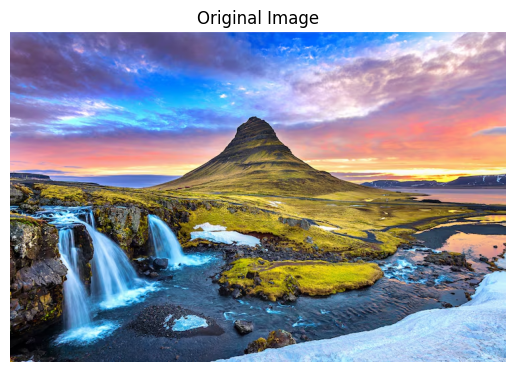

In [ ]:
# Convert BGR to RGB for correct display in matplotlib
# OpenCV uses BGR but matplotlib expects RGB
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img_rgb)
plt.title("Original Image")
plt.axis("off")   # hide axis ticks and labels
plt.show()

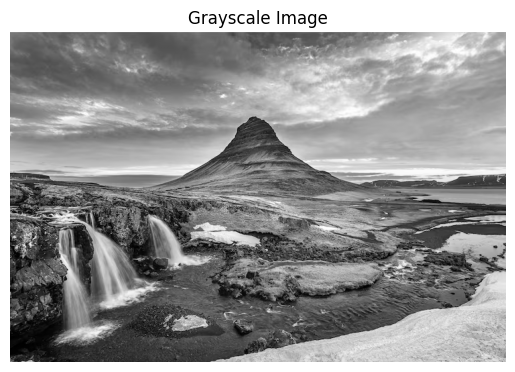

In [ ]:
# Step 2: Convert to grayscale
# grayscale has only 1 channel (intensity) instead of 3 (R,G,B)
# required for most segmentation algorithms
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

plt.imshow(gray, cmap='gray')   # cmap='gray' displays single-channel as grayscale
plt.title("Grayscale Image")
plt.axis("off")
plt.show()

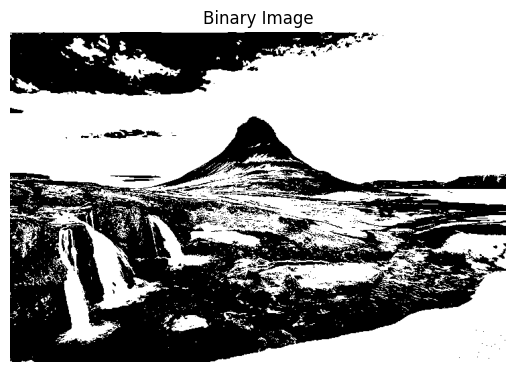

Threshold applied: 120.0


In [ ]:
# Step 3: Apply Binary Thresholding
# pixels above threshold (120) become 255 (white)
# pixels below threshold become 0 (black)
# ret = actual threshold used, binary = result image
ret, binary = cv2.threshold(gray, 120, 255, cv2.THRESH_BINARY)

plt.imshow(binary, cmap='gray')
plt.title("Binary Image")
plt.axis("off")
plt.show()

print(f"Threshold applied: {ret}")

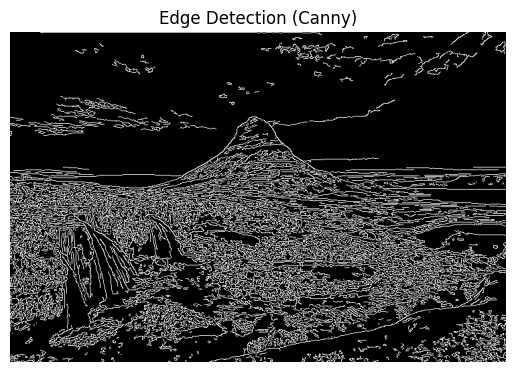

In [ ]:
# Step 4: Edge Detection using Canny
# Canny finds edges by detecting sharp changes in pixel intensity
# 80 = lower threshold (weak edges below this are discarded)
# 180 = upper threshold (strong edges above this are kept)
edges = cv2.Canny(gray, 80, 180)

plt.imshow(edges, cmap='gray')
plt.title("Edge Detection (Canny)")
plt.axis("off")
plt.show()

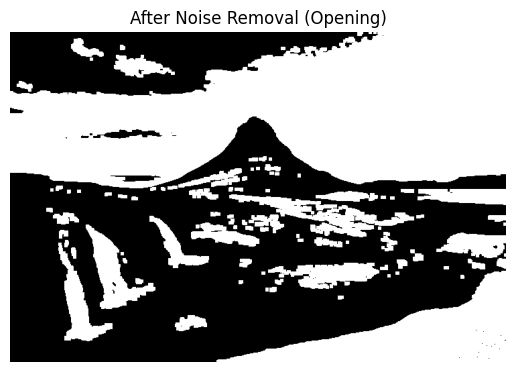

In [ ]:
# Step 5: Morphological Operations (Noise Removal)
# kernel = 3x3 matrix of ones used as the structuring element
kernel = np.ones((3, 3), np.uint8)

# Opening = Erosion followed by Dilation
# Erosion removes small noise/white dots
# Dilation restores the main object shape
# iterations=2 means apply opening twice for stronger noise removal
opening = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel, iterations=2)

plt.imshow(opening, cmap='gray')
plt.title("After Noise Removal (Opening)")
plt.axis("off")
plt.show()

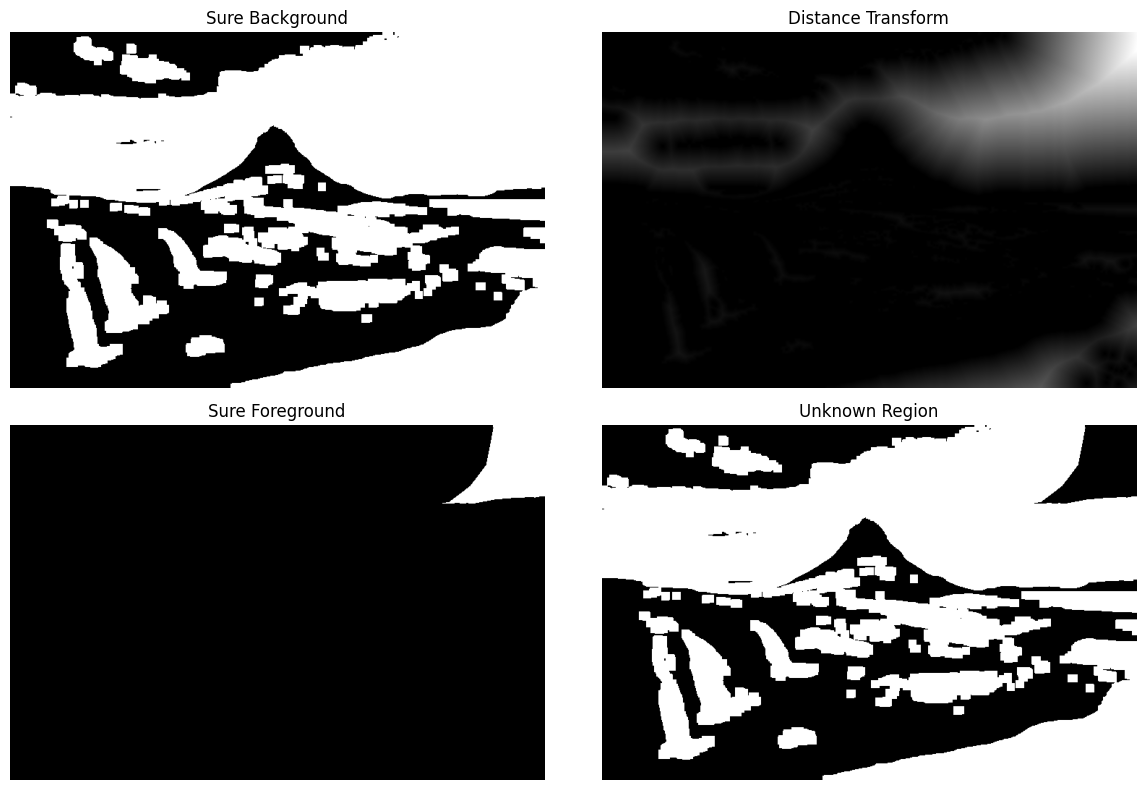

In [ ]:
# Step 6: Background and Foreground Detection

# dilate the opened image 3 times to get the SURE BACKGROUND region
# dilation expands white regions — areas far from foreground are definitely background
sure_bg = cv2.dilate(opening, kernel, iterations=3)

# distance transform: each foreground pixel gets value = distance to nearest background pixel
# pixels far from edges have high values = they are definitely foreground
dist_transform = cv2.distanceTransform(opening, cv2.DIST_L2, 5)

# threshold the distance transform to get the SURE FOREGROUND region
# only keep pixels with distance > 60% of the maximum distance
ret, sure_fg = cv2.threshold(dist_transform, 0.6 * dist_transform.max(), 255, 0)

# convert sure_fg to uint8 (required for further processing)
sure_fg = np.uint8(sure_fg)

# unknown region = sure_bg minus sure_fg
# these pixels are neither clearly background nor foreground — the boundary area
unknown = cv2.subtract(sure_bg, sure_fg)

# display all four results in a 2x2 grid
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.imshow(sure_bg, cmap='gray')
plt.title("Sure Background")
plt.axis("off")

plt.subplot(2, 2, 2)
plt.imshow(dist_transform, cmap='gray')
plt.title("Distance Transform")
plt.axis("off")

plt.subplot(2, 2, 3)
plt.imshow(sure_fg, cmap='gray')
plt.title("Sure Foreground")
plt.axis("off")

plt.subplot(2, 2, 4)
plt.imshow(unknown, cmap='gray')
plt.title("Unknown Region")
plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# Step 7: Marker Labelling for Watershed

# connectedComponents labels each separate white region with a unique integer
# ret = number of components found, markers = label map
ret, markers = cv2.connectedComponents(sure_fg)

# add 1 to all labels so background is 1 (not 0)
# watershed uses 0 as 'unknown', so we shift all values up by 1
markers = markers + 1

# mark the unknown region as 0 — watershed will decide these pixels
markers[unknown == 255] = 0

print(f"Number of regions found: {ret}")
print("Marker values: background=1, unknown=0, objects=2,3,...")

Number of regions found: 2
Marker values: background=1, unknown=0, objects=2,3,...


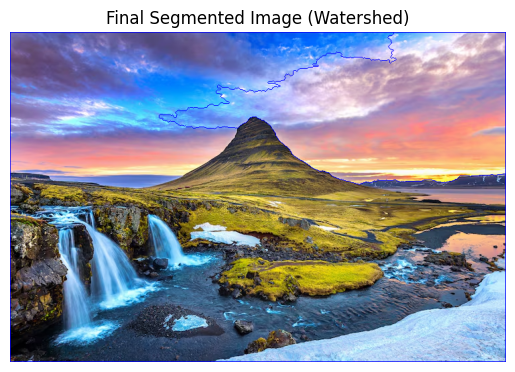

Red lines show the segment boundaries detected by Watershed.


In [ ]:
# Step 8: Apply Watershed Algorithm
# watershed floods the image from the marked regions
# it finds the exact boundary between touching objects
# pixels marked -1 after watershed are boundary pixels
markers = cv2.watershed(img, markers)

# mark detected boundaries in RED color on the original image
# markers == -1 means that pixel is a segment boundary
img[markers == -1] = [255, 0, 0]

# convert back to RGB for display in matplotlib
final_output = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(final_output)
plt.title("Final Segmented Image (Watershed)")
plt.axis("off")
plt.show()

print("Red lines show the segment boundaries detected by Watershed.")

=== Experiment 5: Image Segmentation FROM SCRATCH ===
  URL failed — using synthetic image.
  Image size: 120x120
  Running thresholding...
  Otsu's auto-threshold = 32
  Running edge detection (on resized image for speed)...
  Running region-based segmentation...


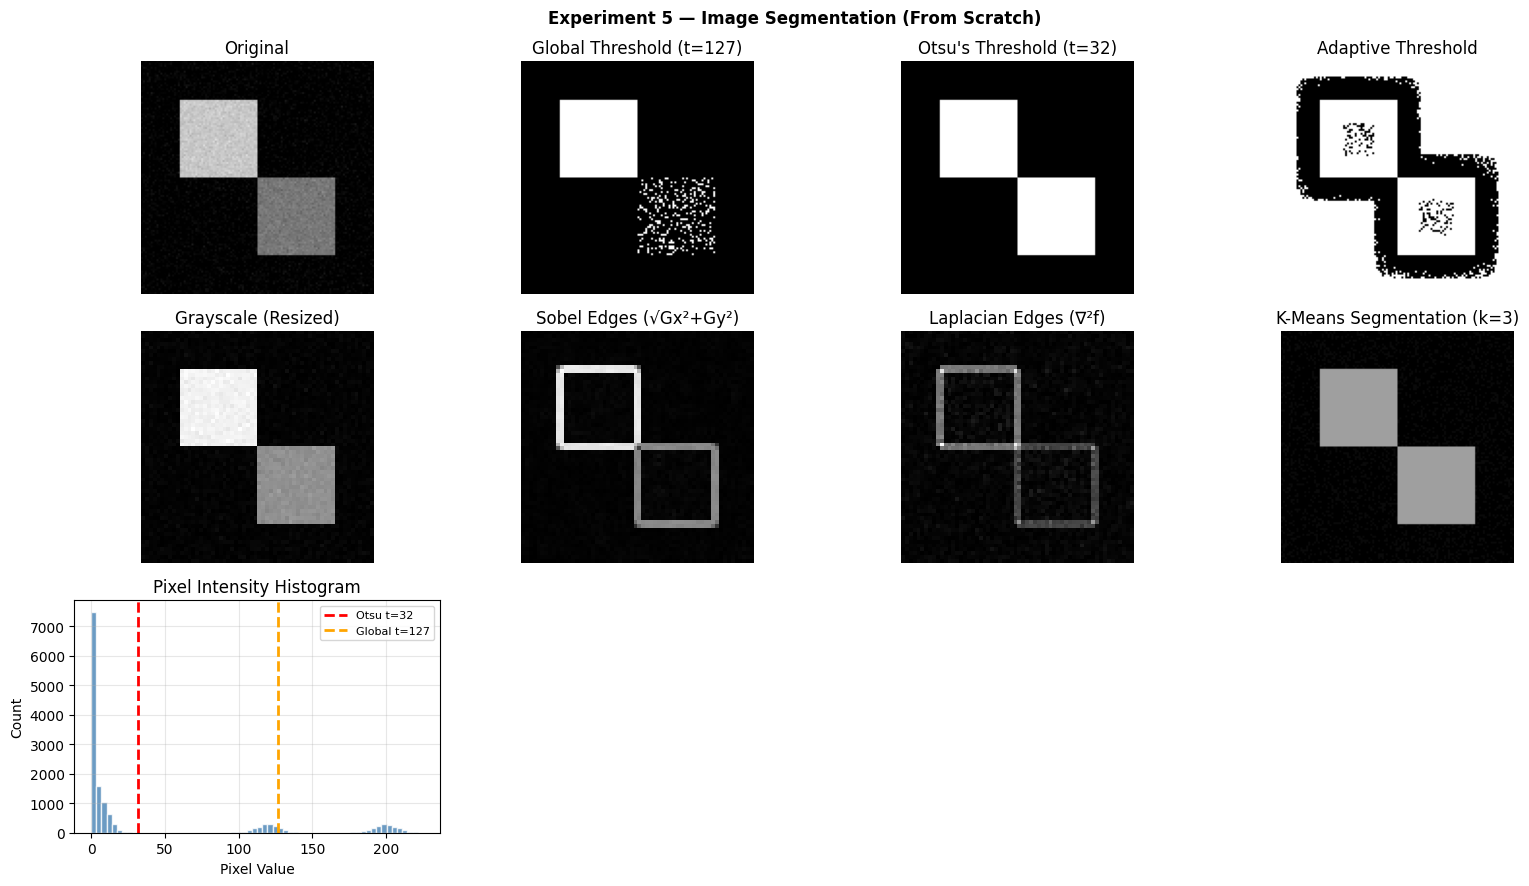

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
from urllib.request import urlretrieve

print("=== Experiment 5: Image Segmentation FROM SCRATCH ===")

# Load image (or fallback to synthetic)
url = "https://upload.wikimedia.org/wikipedia/commons/thumb/4/47/PNG_transparency_demonstration_1.png/280px-PNG_transparency_demonstration_1.png"
try:
    urlretrieve(url, "test_img.png")
    img_bgr  = cv2.imread("test_img.png")
    img_rgb  = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY).astype(np.float64)
    print("  Image loaded from URL.")
except:
    print("  URL failed — using synthetic image.")
    img_gray = np.zeros((120, 120), dtype=np.float64)
    img_gray[20:60, 20:60]  = 200
    img_gray[60:100, 60:100] = 120
    img_gray += np.random.normal(0, 8, img_gray.shape)
    img_gray = np.clip(img_gray, 0, 255)
    img_rgb  = np.stack([img_gray]*3, axis=-1).astype(np.uint8)

H, W = img_gray.shape
print(f"  Image size: {H}x{W}")

# ── Thresholding Functions ──

def global_threshold(gray, thresh=127):
    """Binary: white if pixel >= thresh, else black."""
    out = np.zeros_like(gray, dtype=np.uint8)
    out[gray >= thresh] = 255
    return out

def otsu_threshold(gray):
    """Automatically finds threshold maximising between-class variance."""
    gray_int = gray.astype(np.uint8)
    hist = np.zeros(256)
    for v in gray_int.ravel():
        hist[v] += 1
    hist /= gray_int.size
    best_thresh, best_var = 0, 0
    for t in range(1, 256):
        w0, w1 = hist[:t].sum(), hist[t:].sum()
        if w0 == 0 or w1 == 0:
            continue
        mu0 = np.sum(np.arange(t)    * hist[:t]) / w0
        mu1 = np.sum(np.arange(t,256)* hist[t:]) / w1
        bv  = w0 * w1 * (mu0 - mu1)**2
        if bv > best_var:
            best_var, best_thresh = bv, t
    return global_threshold(gray, best_thresh), best_thresh

def adaptive_threshold(gray, block=25, C=5):
    """Compare each pixel to its local neighbourhood mean."""
    pad = block // 2
    padded = np.pad(gray, pad, mode='reflect')
    out = np.zeros_like(gray, dtype=np.uint8)
    for r in range(H):
        for c in range(W):
            local_mean = padded[r:r+block, c:c+block].mean()
            out[r, c] = 255 if gray[r, c] >= (local_mean - C) else 0
    return out

# ── Edge Detection Functions ──

def convolve2d(img, kernel):
    """Manual 2D convolution — slides kernel over image."""
    kH, kW = kernel.shape
    pH, pW = kH//2, kW//2
    padded = np.pad(img, ((pH,pH),(pW,pW)), mode='reflect')
    out = np.zeros_like(img, dtype=np.float64)
    for r in range(H):
        for c in range(W):
            out[r, c] = np.sum(padded[r:r+kH, c:c+kW] * kernel)
    return out

def sobel_edges(gray):
    """Sobel: detect edges using gradient magnitude."""
    Kx = np.array([[-1,0,1],[-2,0,2],[-1,0,1]], dtype=np.float64)
    Ky = np.array([[-1,-2,-1],[0,0,0],[1,2,1]], dtype=np.float64)
    Gx  = convolve2d(gray, Kx)
    Gy  = convolve2d(gray, Ky)
    mag = np.sqrt(Gx**2 + Gy**2)
    mag = (mag / mag.max() * 255).astype(np.uint8)
    return mag

def laplacian_edges(gray):
    """Laplacian: detect second-order intensity changes."""
    kernel = np.array([[0,1,0],[1,-4,1],[0,1,0]], dtype=np.float64)
    result = np.abs(convolve2d(gray, kernel))
    return (result / result.max() * 255).astype(np.uint8)

print("  Running thresholding...")
binary_global          = global_threshold(img_gray, 127)
binary_otsu, otsu_val  = otsu_threshold(img_gray)
binary_adaptive        = adaptive_threshold(img_gray)
print(f"  Otsu's auto-threshold = {otsu_val}")

# Use a small blurred version for edge detection (speeds up from-scratch convolution)
img_small = cv2.resize(img_gray.astype(np.uint8), (60, 60)).astype(np.float64)
H_s, W_s = img_small.shape
H, W = H_s, W_s   # update for edge functions
print("  Running edge detection (on resized image for speed)...")
sobel_mag  = sobel_edges(img_small)
laplacian  = laplacian_edges(img_small)
H, W = img_gray.shape  # restore

# K-Means region segmentation on pixels (scratch)
print("  Running region-based segmentation...")
np.random.seed(42)
pixels = img_rgb.reshape(-1, 3).astype(np.float64)
K_seg = 3
idx = np.random.choice(len(pixels), K_seg, replace=False)
centroids_seg = pixels[idx].copy()
for _ in range(15):
    dists = np.array([np.sum((pixels - c)**2, axis=1) for c in centroids_seg]).T
    labels_seg = np.argmin(dists, axis=1)
    for k in range(K_seg):
        pts = pixels[labels_seg == k]
        if len(pts) > 0:
            centroids_seg[k] = pts.mean(axis=0)
seg_img = centroids_seg[labels_seg].astype(np.uint8).reshape(img_rgb.shape)

fig = plt.figure(figsize=(16, 9))
fig.suptitle("Experiment 5 — Image Segmentation (From Scratch)", fontweight='bold')

ax = fig.add_subplot(3,4,1);  ax.imshow(img_rgb);              ax.set_title("Original"); ax.axis('off')
ax = fig.add_subplot(3,4,2);  ax.imshow(binary_global,'gray'); ax.set_title("Global Threshold (t=127)"); ax.axis('off')
ax = fig.add_subplot(3,4,3);  ax.imshow(binary_otsu,'gray');   ax.set_title(f"Otsu's Threshold (t={otsu_val})"); ax.axis('off')
ax = fig.add_subplot(3,4,4);  ax.imshow(binary_adaptive,'gray'); ax.set_title("Adaptive Threshold"); ax.axis('off')
ax = fig.add_subplot(3,4,5);  ax.imshow(img_small,'gray');     ax.set_title("Grayscale (Resized)"); ax.axis('off')
ax = fig.add_subplot(3,4,6);  ax.imshow(sobel_mag,'gray');     ax.set_title("Sobel Edges (√Gx²+Gy²)"); ax.axis('off')
ax = fig.add_subplot(3,4,7);  ax.imshow(laplacian,'gray');     ax.set_title("Laplacian Edges (∇²f)"); ax.axis('off')
ax = fig.add_subplot(3,4,8);  ax.imshow(seg_img);              ax.set_title("K-Means Segmentation (k=3)"); ax.axis('off')
ax = fig.add_subplot(3,4,9)
ax.hist(img_gray.ravel(), bins=64, color='steelblue', edgecolor='white', alpha=0.8)
ax.axvline(otsu_val, color='red', linestyle='--', lw=2, label=f'Otsu t={otsu_val}')
ax.axvline(127, color='orange', linestyle='--', lw=2, label='Global t=127')
ax.set(title='Pixel Intensity Histogram', xlabel='Pixel Value', ylabel='Count')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

# Experiment No 6: -Semantic Segmentation using deep learning models

**Theory:**

1. Semantic Segmentation assigns a class label to every pixel in the image
2. FCN replaces dense (fully connected) layers with convolutional layers so the output is a full segmentation map
3. Encoder: Conv + Pool — extracts features and reduces size
4. Decoder: UpSampling + Conv — restores original image size
5. Final layer: sigmoid activation gives pixel-wise probability (0=background, 1=foreground)


### Semantic Segmentation using LIBRARIES

In [ ]:
# import all required libraries
import numpy as np
import matplotlib.pyplot as plt

# tensorflow and keras for building the deep learning model
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [ ]:
# Step 1: Load MNIST Dataset
# MNIST has 60000 training images and 10000 test images
# each image is 28x28 grayscale, showing digits 0-9
(x_train, _), (x_test, _) = keras.datasets.mnist.load_data()

# normalize pixel values from 0-255 to 0-1
# helps the model train faster and more stably
x_train = x_train / 255.0
x_test  = x_test  / 255.0

# create segmentation masks (ground truth)
# any pixel with value > 0 belongs to the digit (label=1)
# background pixels have value 0 (label=0)
y_train = (x_train > 0).astype(np.float32)
y_test  = (x_test  > 0).astype(np.float32)

# add channel dimension: (60000, 28, 28) → (60000, 28, 28, 1)
# Keras CNN layers expect 4D input: (batch, height, width, channels)
x_train = x_train[..., np.newaxis]
x_test  = x_test[..., np.newaxis]
y_train = y_train[..., np.newaxis]
y_test  = y_test[..., np.newaxis]

print("x_train shape:", x_train.shape)
print("y_train shape:", y_train.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
x_train shape: (60000, 28, 28, 1)
y_train shape: (60000, 28, 28, 1)


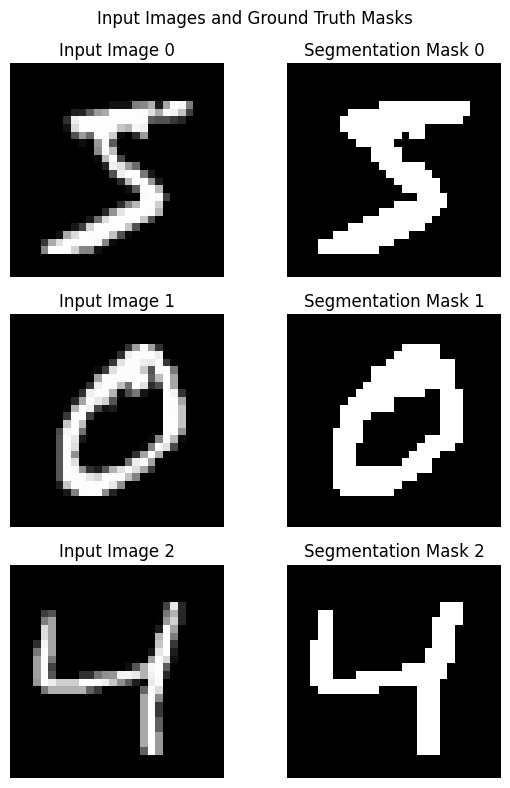

In [ ]:
# Step 2: Visualize sample images and their segmentation masks
fig, axes = plt.subplots(3, 2, figsize=(6, 8))

for i in range(3):
    # original image
    axes[i, 0].imshow(x_train[i].squeeze(), cmap='gray')
    axes[i, 0].set_title(f'Input Image {i}')
    axes[i, 0].axis('off')

    # ground truth mask
    axes[i, 1].imshow(y_train[i].squeeze(), cmap='gray')
    axes[i, 1].set_title(f'Segmentation Mask {i}')
    axes[i, 1].axis('off')

plt.suptitle('Input Images and Ground Truth Masks')
plt.tight_layout()
plt.show()

In [ ]:
# Step 3: Build the FCN Model

# define input layer — accepts 28x28 single-channel images
inputs = keras.Input(shape=(28, 28, 1))

# --- Encoder (Downsampling) ---
# Conv2D(16, 3) = 16 filters of size 3x3
# padding='same' keeps the output the same size as input
# activation='relu' removes negative values
x = layers.Conv2D(16, 3, activation='relu', padding='same')(inputs)
# MaxPooling2D reduces spatial size by half: 28x28 → 14x14
x = layers.MaxPooling2D()(x)

# second conv block with more filters to learn complex features
x = layers.Conv2D(32, 3, activation='relu', padding='same')(x)
# size: 14x14 → 7x7
x = layers.MaxPooling2D()(x)

# bottleneck: deepest part with most abstract features
x = layers.Conv2D(64, 3, activation='relu', padding='same')(x)

# --- Decoder (Upsampling) ---
# UpSampling2D doubles the spatial size: 7x7 → 14x14
x = layers.UpSampling2D()(x)
x = layers.Conv2D(32, 3, activation='relu', padding='same')(x)

# 14x14 → 28x28 (back to original size)
x = layers.UpSampling2D()(x)
x = layers.Conv2D(16, 3, activation='relu', padding='same')(x)

# final layer: 1x1 conv with sigmoid gives one probability per pixel
# sigmoid output: 0 = background, 1 = foreground (digit)
outputs = layers.Conv2D(1, 1, activation='sigmoid')(x)

# create the model
model = keras.Model(inputs, outputs)

# print model architecture summary
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 1)      │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 46,401 (181.25 KB)

 Trainable params: 46,401 (181.25 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Step 4: Compile the Model
# optimizer='adam' = adaptive learning rate optimizer (works well in practice)
# loss='binary_crossentropy' = suitable for binary pixel-wise classification
# metrics=['accuracy'] = track pixel accuracy during training
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
# Step 5: Train the Model
# epochs=5 means go through the full dataset 5 times
# batch_size=32 means process 32 images at a time
# validation_split=0.1 means use 10% of training data for validation
history = model.fit(
    x_train, y_train,
    epochs=4,
    batch_size=30,
    validation_split=0.1,
    verbose=1
)

Epoch 1/4
1800/1800 ━━━━━━━━━━━━━━━━━━━━ 15s 5ms/step - accuracy: 0.9776 - loss: 0.0559 - val_accuracy: 0.9823 - val_loss: 0.0420
Epoch 2/4
1800/1800 ━━━━━━━━━━━━━━━━━━━━ 16s 4ms/step - accuracy: 0.9870 - loss: 0.0319 - val_accuracy: 0.9891 - val_loss: 0.0269
Epoch 3/4
1800/1800 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9917 - loss: 0.0214 - val_accuracy: 0.9928 - val_loss: 0.0194
Epoch 4/4
1800/1800 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9944 - loss: 0.0148 - val_accuracy: 0.9953 - val_loss: 0.0128


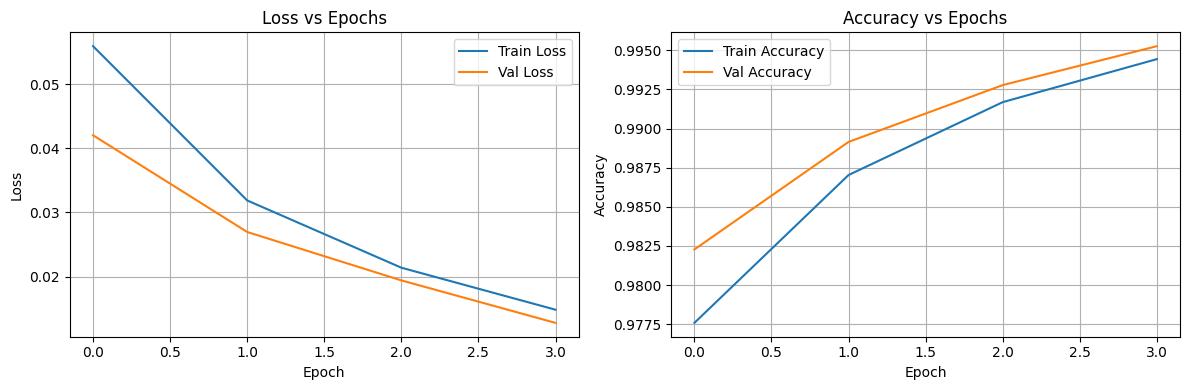

In [ ]:
# Step 6: Plot Training History
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# plot loss curve
axes[0].plot(history.history['loss'], label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].set_title('Loss vs Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

# plot accuracy curve
axes[1].plot(history.history['accuracy'], label='Train Accuracy')
axes[1].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[1].set_title('Accuracy vs Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


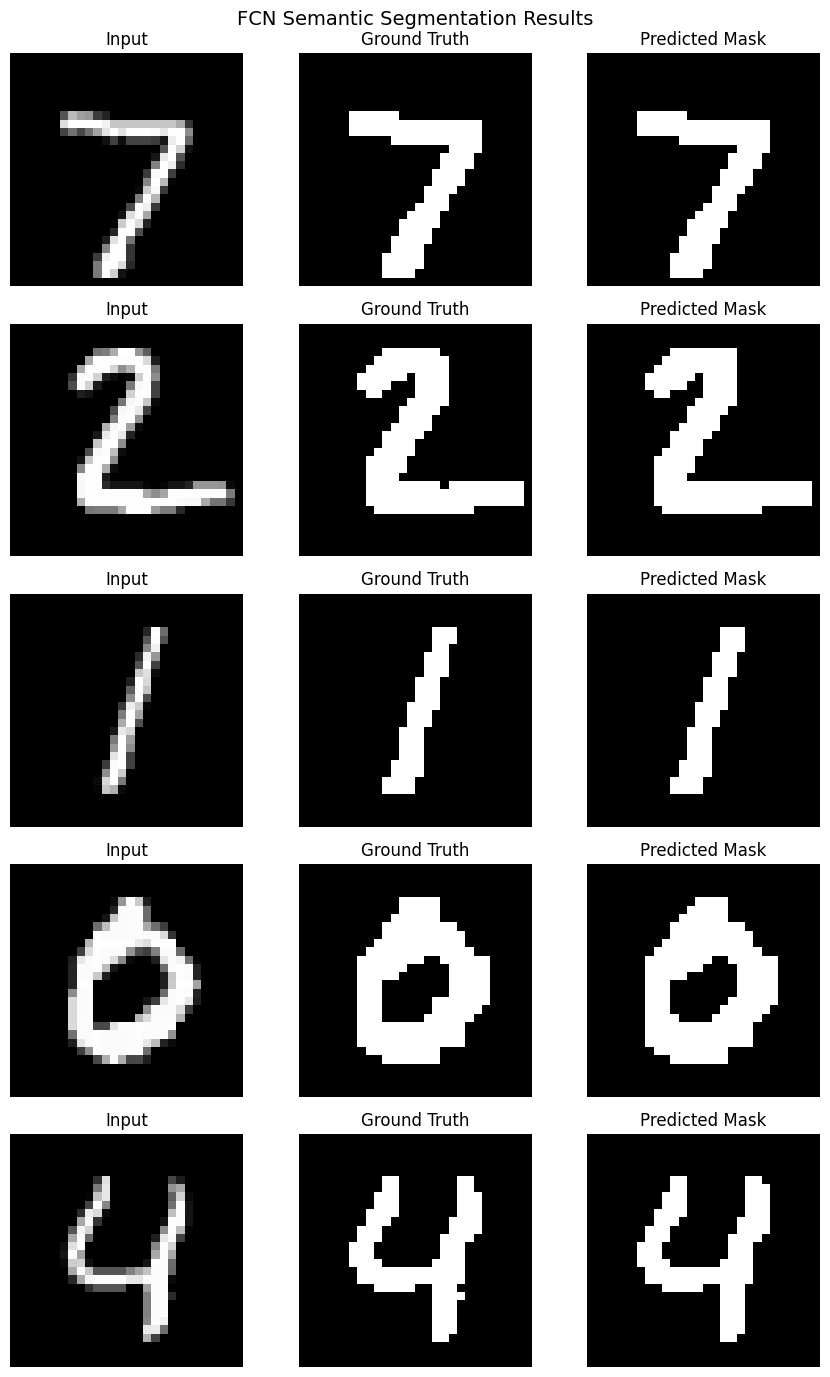

In [ ]:
# Step 7: Predict and Visualize Segmentation Results
# generate predictions for first 5 test images
preds = model.predict(x_test[:5])

fig, axes = plt.subplots(5, 3, figsize=(9, 14))

for i in range(5):
    # original image
    axes[i, 0].imshow(x_test[i].squeeze(), cmap='gray')
    axes[i, 0].set_title('Input')
    axes[i, 0].axis('off')

    # ground truth mask
    axes[i, 1].imshow(y_test[i].squeeze(), cmap='gray')
    axes[i, 1].set_title('Ground Truth')
    axes[i, 1].axis('off')

    # predicted mask (threshold at 0.5)
    # pixels with probability > 0.5 are classified as foreground
    axes[i, 2].imshow(preds[i].squeeze() > 0.5, cmap='gray')
    axes[i, 2].set_title('Predicted Mask')
    axes[i, 2].axis('off')

plt.suptitle('FCN Semantic Segmentation Results', fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
# Step 8: Evaluate on Test Set
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f"Test Loss     = {test_loss:.4f}")
print(f"Test Accuracy = {test_acc * 100:.2f}%")

Test Loss     = 0.0122
Test Accuracy = 99.55%


=== Experiment 6: Semantic Segmentation FROM SCRATCH (MLP) ===
  Epoch 100 | Loss = 0.0810
  Epoch 200 | Loss = 0.0208
  Epoch 300 | Loss = 0.0110
  Pixel-wise Accuracy = 100.00%


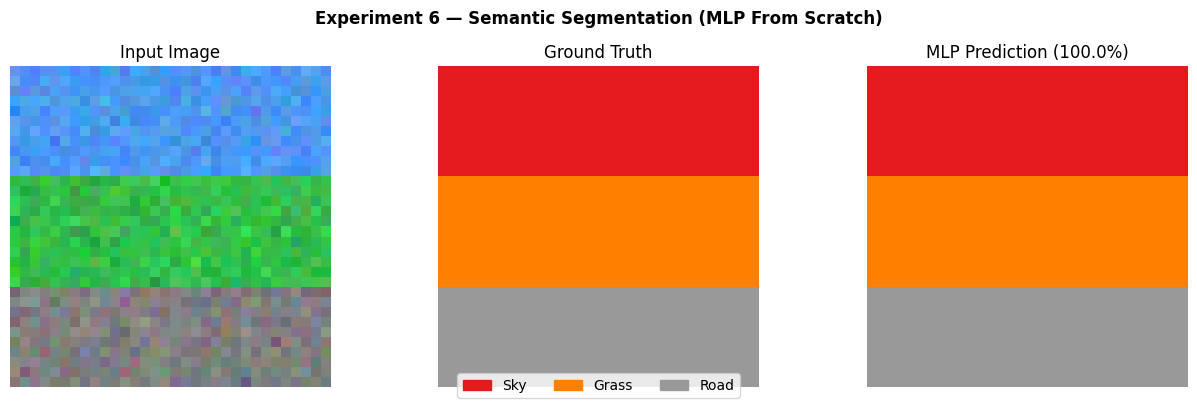

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib

np.random.seed(7)
H_s, W_s = 32, 32

print("=== Experiment 6: Semantic Segmentation FROM SCRATCH (MLP) ===")

# Synthetic 3-class landscape image (Sky / Grass / Road)
image = np.zeros((H_s, W_s, 3), dtype=np.float32)
ground_truth = np.zeros((H_s, W_s), dtype=np.int32)
image[:11]   = np.clip([0.3, 0.6, 0.95] + np.random.normal(0, 0.05, (11, W_s, 3)), 0, 1)
image[11:22] = np.clip([0.2, 0.75, 0.3] + np.random.normal(0, 0.05, (11, W_s, 3)), 0, 1)
image[22:]   = np.clip([0.5, 0.5, 0.5]  + np.random.normal(0, 0.05, (10, W_s, 3)), 0, 1)
ground_truth[:11]  = 0   # Sky
ground_truth[11:22]= 1   # Grass
ground_truth[22:]  = 2   # Road

X_pix = image.reshape(-1, 3)          # (1024, 3)
y_pix = ground_truth.flatten()        # (1024,)

def one_hot(labels, n):
    oh = np.zeros((len(labels), n))
    oh[np.arange(len(labels)), labels] = 1
    return oh

Y_oh = one_hot(y_pix, 3)

def relu(z):        return np.maximum(0, z)
def relu_grad(z):   return (z > 0).astype(float)
def softmax(z):
    e = np.exp(z - np.max(z, axis=1, keepdims=True))
    return e / e.sum(axis=1, keepdims=True)
def cross_entropy(y_pred, y_true):
    return -np.sum(y_true * np.log(y_pred + 1e-9)) / len(y_pred)

# Network: 3 → 16 → 3
W1 = np.random.randn(3, 16) * 0.1;  b1 = np.zeros((1, 16))
W2 = np.random.randn(16, 3) * 0.1;  b2 = np.zeros((1, 3))
lr = 0.5;  loss_curve = []

for epoch in range(300):
    # Forward pass
    Z1, A1 = X_pix @ W1 + b1, relu(X_pix @ W1 + b1) # linear combination: input → hidden layer, apply ReLU: remove negative values
    Z2 = A1 @ W2 + b2;  A2 = softmax(Z2) # linear combination: hidden → output layer, apply softmax: convert scores to probabilities
    loss_curve.append(cross_entropy(A2, Y_oh))
    # Backpropagation
    dZ2 = A2 - Y_oh
    dW2 = A1.T @ dZ2 / len(X_pix);  db2 = dZ2.mean(axis=0, keepdims=True)
    dA1 = dZ2 @ W2.T;  dZ1 = dA1 * relu_grad(X_pix @ W1 + b1)
    dW1 = X_pix.T @ dZ1 / len(X_pix);  db1 = dZ1.mean(axis=0, keepdims=True)
    W1 -= lr*dW1;  b1 -= lr*db1
    W2 -= lr*dW2;  b2 -= lr*db2
    if (epoch+1) % 100 == 0:
        print(f"  Epoch {epoch+1:3d} | Loss = {loss_curve[-1]:.4f}")

A1_f = relu(X_pix @ W1 + b1)
A2_f = softmax(A1_f @ W2 + b2)
pred_labels = np.argmax(A2_f, axis=1).reshape(H_s, W_s)
accuracy = np.mean(np.argmax(A2_f, axis=1) == y_pix) * 100
print(f"  Pixel-wise Accuracy = {accuracy:.2f}%")

cmap3 = matplotlib.colormaps['Set1'].resampled(3)
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
fig.suptitle("Experiment 6 — Semantic Segmentation (MLP From Scratch)", fontweight='bold')
axes[0].imshow(image);  axes[0].set_title("Input Image");  axes[0].axis('off')
axes[1].imshow(ground_truth, cmap=cmap3, vmin=0, vmax=2);  axes[1].set_title("Ground Truth");  axes[1].axis('off')
axes[2].imshow(pred_labels, cmap=cmap3, vmin=0, vmax=2);   axes[2].set_title(f"MLP Prediction ({accuracy:.1f}%)"); axes[2].axis('off')
import matplotlib.patches as mpatches
patches = [mpatches.Patch(color=cmap3(i), label=['Sky','Grass','Road'][i]) for i in range(3)]
fig.legend(handles=patches, loc='lower center', ncol=3, fontsize=10)
plt.tight_layout()
plt.show()

# Experiment No 7: - Instance segmentation using deep learning models

**Theory:**

1. U-Net is an encoder-decoder architecture designed for precise segmentation
2. Skip Connections: Feature maps from encoder are directly concatenated to decoder layers
3. This recovers spatial detail lost during pooling
Encoder: Conv → Pool (extract features, reduce size)
4. Bottleneck: deepest layer
5. Decoder: UpSampling → Concatenate with encoder → Conv (restore size)
6. The 'U' shape comes from its architecture diagram

In [ ]:
# import required libraries
import numpy as np
import matplotlib.pyplot as plt

# tensorflow and keras for building the U-Net
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [ ]:
# Step 1: Load and Prepare MNIST Dataset
(x_train, _), (x_test, _) = keras.datasets.mnist.load_data()

# normalize pixel values to 0-1 range
x_train = x_train / 255.0
x_test  = x_test  / 255.0

# create binary segmentation masks as ground truth
# pixel > 0 means it's part of the digit → label 1
# pixel == 0 means background → label 0
y_train = (x_train > 0).astype(np.float32)
y_test  = (x_test  > 0).astype(np.float32)

# add channel dimension for Keras CNN compatibility
# shape: (60000, 28, 28) → (60000, 28, 28, 1)
x_train = x_train[..., np.newaxis]
x_test  = x_test[..., np.newaxis]
y_train = y_train[..., np.newaxis]
y_test  = y_test[..., np.newaxis]

print("Training data shape:", x_train.shape)
print("Mask shape:", y_train.shape)

Training data shape: (60000, 28, 28, 1)
Mask shape: (60000, 28, 28, 1)


In [ ]:
# Step 2: Build the U-Net Architecture

# input layer: 28x28 single-channel image
inputs = layers.Input((28, 28, 1))

# ===================== ENCODER =====================
# first encoder block: 16 filters, 3x3 kernel
# padding='same' keeps size the same after convolution
c1 = layers.Conv2D(16, 3, activation='relu', padding='same')(inputs)
# save c1 — will be used in skip connection later
p1 = layers.MaxPooling2D()(c1)   # 28x28 → 14x14

# second encoder block: 32 filters
c2 = layers.Conv2D(32, 3, activation='relu', padding='same')(p1)
# save c2 — will be used in skip connection later
p2 = layers.MaxPooling2D()(c2)   # 14x14 → 7x7

# ===================== BOTTLENECK =====================
# deepest layer with 64 filters — most abstract features
b = layers.Conv2D(64, 3, activation='relu', padding='same')(p2)

# ===================== DECODER =====================
# first decoder block: upsample to restore spatial size
u1 = layers.UpSampling2D()(b)       # 7x7 → 14x14

# SKIP CONNECTION: concatenate decoder output with encoder c2
# this adds the detailed spatial info from encoder back to decoder
# Concatenate merges channels: 32 (from u1) + 32 (from c2) = 64 channels
u1 = layers.Concatenate()([u1, c2])
u1 = layers.Conv2D(32, 3, activation='relu', padding='same')(u1)

# second decoder block
u2 = layers.UpSampling2D()(u1)      # 14x14 → 28x28

# SKIP CONNECTION: concatenate with encoder c1
# this is the key U-Net feature — fine details are restored here
u2 = layers.Concatenate()([u2, c1])
u2 = layers.Conv2D(16, 3, activation='relu', padding='same')(u2)

# ===================== OUTPUT =====================
# 1x1 convolution: reduces channels to 1
# sigmoid activation: each pixel gets a probability (0=background, 1=digit)
outputs = layers.Conv2D(1, 1, activation='sigmoid')(u2)

# create the U-Net model
model = Model(inputs, outputs)

# print architecture
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 28, 28,    │        160 │ input_layer_1[0]… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 14, 14,    │          0 │ conv2d_6[0][0]    │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 14, 14,    │      4,640 │ max_pooling2d_2[… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 7, 7, 32)  │          0 │ conv2d_7[0][0]    │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 7, 7, 64)  │     18,496 │ max_pooling2d_3[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_2     │ (None, 14, 14,    │          0 │ conv2d_8[0][0]    │
│ (UpSampling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 14, 14,    │          0 │ up_sampling2d_2[… │
│ (Concatenate)       │ 96)               │            │ conv2d_7[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 14, 14,    │     27,680 │ concatenate[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_3     │ (None, 28, 28,    │          0 │ conv2d_9[0][0]    │
│ (UpSampling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 28, 28,    │          0 │ up_sampling2d_3[… │
│ (Concatenate)       │ 48)               │            │ conv2d_6[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_10 (Conv2D)  │ (None, 28, 28,    │      6,928 │ concatenate_1[0]… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_11 (Conv2D)  │ (None, 28, 28, 1) │         17 │ conv2d_10[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 57,921 (226.25 KB)

 Trainable params: 57,921 (226.25 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Step 3: Compile the Model
# adam optimizer automatically adjusts learning rate
# binary_crossentropy is used because each pixel is a binary decision
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
# Step 4: Train the Model
# batch_size=32: process 32 images at a time
# epochs=5: go through entire dataset 5 times
# validation_split=0.1: hold out 10% for validation
history = model.fit(
    x_train, y_train,
    epochs=5,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 16s 7ms/step - accuracy: 0.9892 - loss: 0.0297 - val_accuracy: 0.9963 - val_loss: 0.0127
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9980 - loss: 0.0068 - val_accuracy: 0.9987 - val_loss: 0.0041
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9992 - loss: 0.0030 - val_accuracy: 0.9992 - val_loss: 0.0023
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9996 - loss: 0.0015 - val_accuracy: 0.9997 - val_loss: 9.9230e-04
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9998 - loss: 7.2056e-04 - val_accuracy: 0.9998 - val_loss: 5.5902e-04


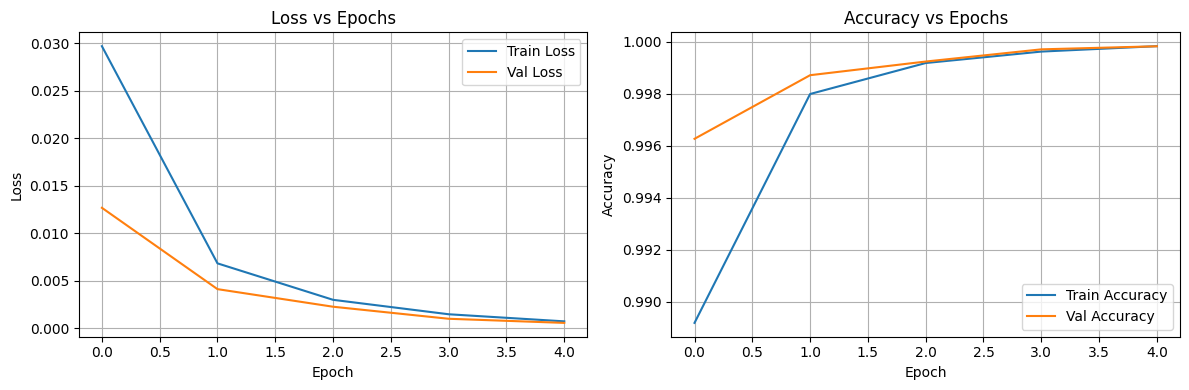

In [ ]:
# Step 5: Plot Training History
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# loss
axes[0].plot(history.history['loss'], label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].set_title('Loss vs Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

# accuracy
axes[1].plot(history.history['accuracy'], label='Train Accuracy')
axes[1].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[1].set_title('Accuracy vs Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 567ms/step


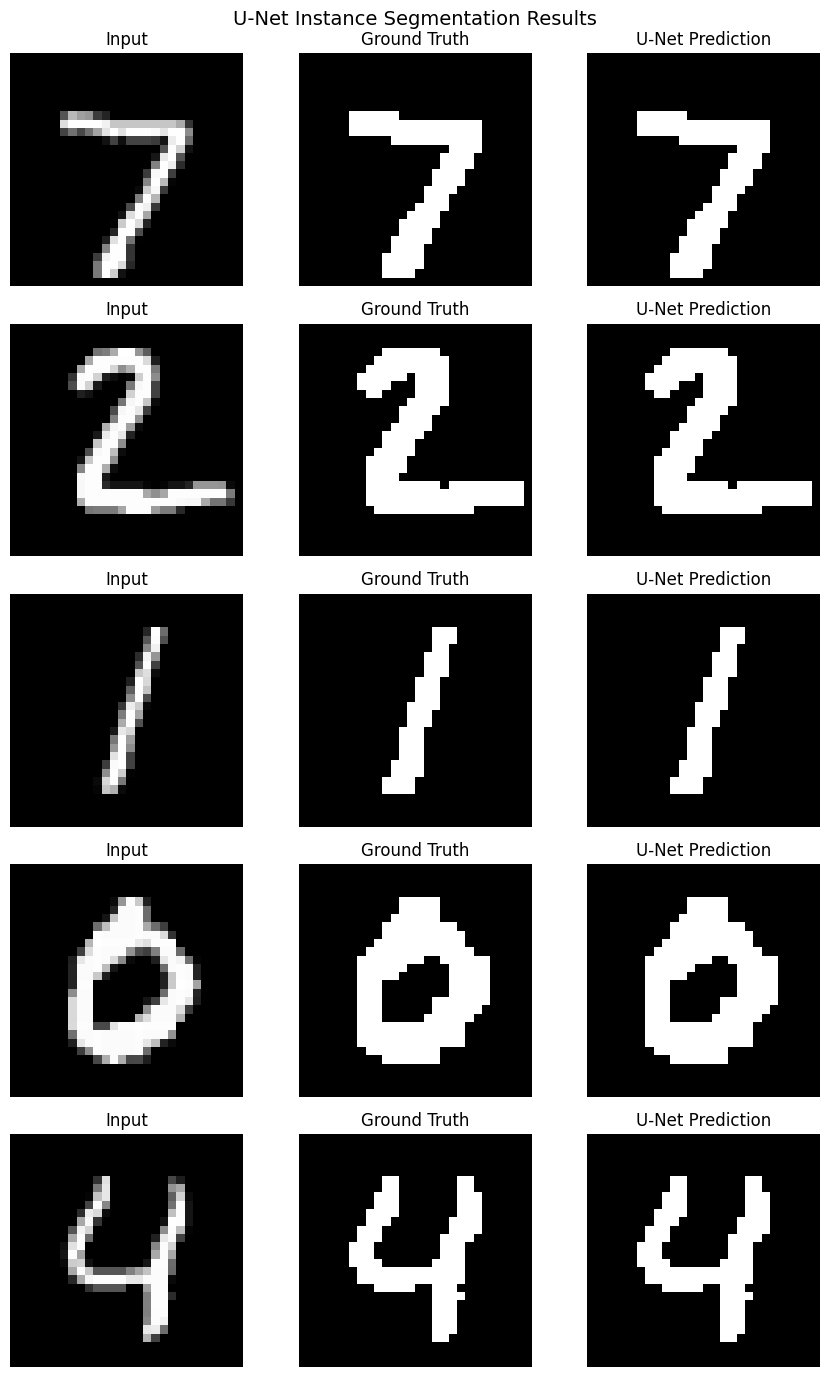

In [ ]:
# Step 6: Visualize Predictions
# predict masks for first 5 test images
preds = model.predict(x_test[:5])

fig, axes = plt.subplots(5, 3, figsize=(9, 14))

for i in range(5):
    # original digit image
    axes[i, 0].imshow(x_test[i].squeeze(), cmap='gray')
    axes[i, 0].set_title('Input')
    axes[i, 0].axis('off')

    # ground truth mask
    axes[i, 1].imshow(y_test[i].squeeze(), cmap='gray')
    axes[i, 1].set_title('Ground Truth')
    axes[i, 1].axis('off')

    # U-Net predicted mask (threshold at 0.5)
    axes[i, 2].imshow(preds[i].squeeze() > 0.5, cmap='gray')
    axes[i, 2].set_title('U-Net Prediction')
    axes[i, 2].axis('off')

plt.suptitle('U-Net Instance Segmentation Results', fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
# Step 7: Compare FCN vs U-Net
# U-Net advantage: skip connections preserve fine digit boundaries
# The segmentation is sharper and more accurate than plain FCN
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f"U-Net Test Loss     = {test_loss:.4f}")
print(f"U-Net Test Accuracy = {test_acc * 100:.2f}%")
print("\nU-Net achieves higher accuracy than plain FCN due to skip connections.")
print("Skip connections pass encoder feature maps directly to the decoder,")
print("helping the model recover fine spatial details lost during pooling.")

U-Net Test Loss     = 0.0005
U-Net Test Accuracy = 99.98%

U-Net achieves higher accuracy than plain FCN due to skip connections.
Skip connections pass encoder feature maps directly to the decoder,
helping the model recover fine spatial details lost during pooling.


### U-Net FROM SCRATCH

=== Experiment 7: Instance Segmentation — U-Net FROM SCRATCH ===
  Pixel accuracy (8x8 demo with skip connection) = 62.5%


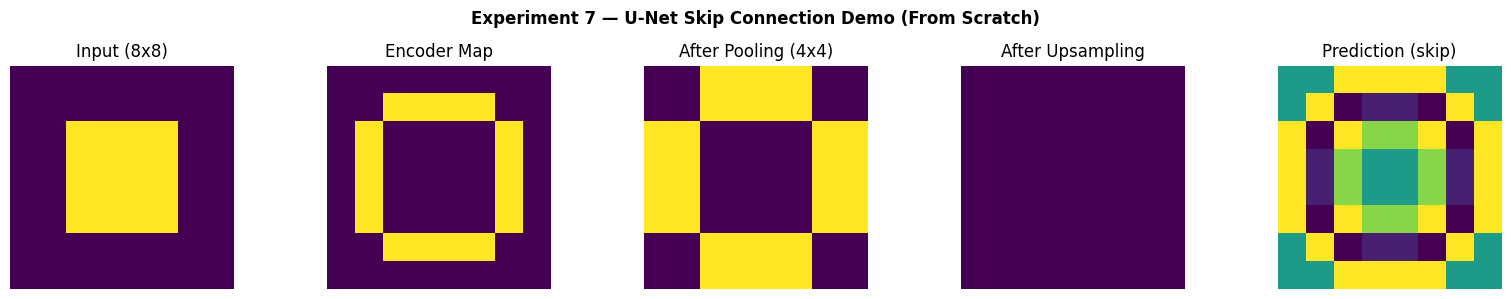

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

print("=== Experiment 7: Instance Segmentation — U-Net FROM SCRATCH ===")

np.random.seed(42)

# We build a simplified single-image demo of how skip connections work
# using a tiny 8x8 grayscale image with numpy-only operations

def relu(z):      return np.maximum(0, z)
def sigmoid_fn(z): return 1 / (1 + np.exp(-z))

def conv2d_simple(img, kernel):
    """Simple 3x3 convolution with 'same' padding."""
    kH, kW = kernel.shape
    pH, pW = kH//2, kW//2
    padded = np.pad(img, ((pH,pH),(pW,pW)), mode='reflect')
    H, W   = img.shape
    out = np.zeros((H, W))
    for r in range(H):
        for c in range(W):
            out[r, c] = np.sum(padded[r:r+kH, c:c+kW] * kernel)
    return out

def maxpool2x2(img):
    """2x2 max pooling — reduces size by half."""
    H, W = img.shape
    out = np.zeros((H//2, W//2))
    for r in range(H//2):
        for c in range(W//2):
            out[r, c] = img[2*r:2*r+2, 2*c:2*c+2].max()
    return out

def upsample2x(img):
    """Nearest-neighbour upsampling — doubles size."""
    H, W = img.shape
    out = np.zeros((H*2, W*2))
    for r in range(H):
        for c in range(W):
            out[2*r:2*r+2, 2*c:2*c+2] = img[r, c]
    return out

# Synthetic 8x8 binary image with a square in centre
x_in = np.zeros((8, 8))
x_in[2:6, 2:6] = 1.0    # square = foreground
gt   = x_in.copy()

# Random edge-detection kernel
K_edge = np.array([[0,1,0],[1,-4,1],[0,1,0]], dtype=np.float64)

# ENCODER
enc1 = relu(conv2d_simple(x_in, K_edge))   # 8x8  feature map
pool1 = maxpool2x2(enc1)                    # 4x4

# BOTTLENECK
bottleneck = relu(conv2d_simple(pool1, np.ones((3,3))/9))  # 4x4

# DECODER (with skip connection from enc1)
up1  = upsample2x(bottleneck)              # 8x8
# Skip connection: add encoder feature map
skip_fused = up1 + enc1                    # 8x8 (element-wise add)
pred_map   = sigmoid_fn(conv2d_simple(skip_fused, K_edge))  # 8x8 probability map

acc_scratch = np.mean((pred_map > 0.5).astype(int) == gt.astype(int)) * 100
print(f"  Pixel accuracy (8x8 demo with skip connection) = {acc_scratch:.1f}%")

fig, axes = plt.subplots(1, 5, figsize=(16, 3))
fig.suptitle("Experiment 7 — U-Net Skip Connection Demo (From Scratch)", fontweight='bold')
titles = ['Input (8x8)', 'Encoder Map', 'After Pooling (4x4)', 'After Upsampling', 'Prediction (skip)']
imgs   = [x_in, enc1, pool1, up1, pred_map]
for ax, img, title in zip(axes, imgs, titles):
    ax.imshow(img, cmap='viridis'); ax.set_title(title); ax.axis('off')
plt.tight_layout()
plt.show()

# Experiment No 8: - Build a CNN architecture for image classification on a dataset like CIFAR-10 or MNIST.

**Theory:**

1. **Convolution Layer:** Applies learned filters to extract features (edges, patterns)
2. **ReLU Activation:** Removes negative values — adds non-linearity
3. **MaxPooling:** Reduces spatial size — keeps most important features
4. **Flatten:** Converts 2D feature maps to 1D vector
5. **Dense Layer:** Fully connected layer for classification
6. **Softmax:** Converts scores to class probabilities (all sum to 1)

In [ ]:
# import all required libraries
import numpy as np
import matplotlib.pyplot as plt

# tensorflow and keras for building the CNN
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [ ]:
# Step 1: Load the MNIST Dataset
# returns training and test splits with images and labels
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

print("Training images:", x_train.shape)   # (60000, 28, 28)
print("Training labels:", y_train.shape)   # (60000,)
print("Test images:",     x_test.shape)    # (10000, 28, 28)
print("Test labels:",     y_test.shape)    # (10000,)

Training images: (60000, 28, 28)
Training labels: (60000,)
Test images: (10000, 28, 28)
Test labels: (10000,)


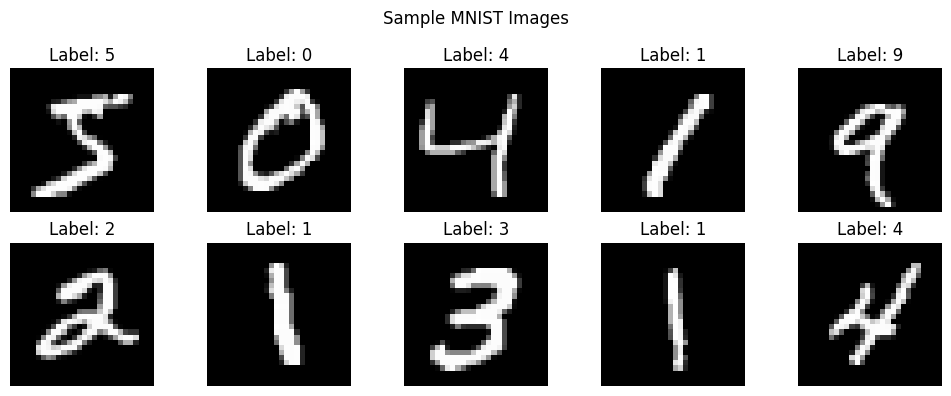

In [ ]:
# Step 2: Visualize Sample Images
plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(f'Label: {y_train[i]}')
    plt.axis('off')
plt.suptitle('Sample MNIST Images')
plt.tight_layout()
plt.show()

In [ ]:
# Step 3: Preprocess the Data

# normalize pixel values from 0-255 to 0-1
# helps gradient descent converge faster
x_train = x_train / 255.0
x_test  = x_test  / 255.0

# add channel dimension: (60000, 28, 28) → (60000, 28, 28, 1)
# CNN layers expect 4D input: (batch_size, height, width, channels)
x_train = x_train[..., np.newaxis]
x_test  = x_test[..., np.newaxis]

print("x_train shape after preprocessing:", x_train.shape)

x_train shape after preprocessing: (60000, 28, 28, 1)


In [ ]:
# Step 4: Build the CNN Architecture
model = keras.Sequential([

    # --- First Convolutional Block ---
    # Conv2D(32, 3): 32 filters of size 3x3 — learns 32 different features
    # activation='relu': removes negative values (max(0, x))
    # padding='same': output size = input size (28x28)
    # input_shape=(28,28,1): first layer must specify input dimensions
    layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(28, 28, 1)),

    # MaxPooling: reduces 28x28 to 14x14 by taking max in each 2x2 block
    layers.MaxPooling2D((2, 2)),

    # --- Second Convolutional Block ---
    # 64 filters: learns more complex features
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),

    # MaxPooling: reduces 14x14 to 7x7
    layers.MaxPooling2D((2, 2)),

    # --- Third Convolutional Block ---
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),

    # --- Flatten ---
    # converts 3D feature map (7, 7, 64) → 1D vector (3136,)
    # required before dense layers
    layers.Flatten(),

    # --- Dense (Fully Connected) Layer ---
    # 64 neurons with ReLU activation
    layers.Dense(64, activation='relu'),

    # Dropout: randomly turns off 50% of neurons during training
    # prevents overfitting — forces the network to learn robust features
    layers.Dropout(0.5),

    # --- Output Layer ---
    # 10 neurons = 10 digit classes (0 to 9)
    # softmax converts scores to probabilities that sum to 1
    layers.Dense(10, activation='softmax')
])

# print the architecture
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 7, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       200,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 257,162 (1004.54 KB)

 Trainable params: 257,162 (1004.54 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Step 5: Compile the Model
# optimizer='adam': adaptive learning rate — good default for most problems
# loss='sparse_categorical_crossentropy': used for integer class labels (0,1,...9)
# metrics=['accuracy']: track classification accuracy during training
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
# Step 6: Train the Model
# epochs=10: go through the full dataset 10 times
# batch_size=64: process 64 images per weight update step
# validation_split=0.1: use 10% of training data to monitor overfitting
history = model.fit(
    x_train, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.1,
    verbose=1
)

Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.9154 - loss: 0.2780 - val_accuracy: 0.9848 - val_loss: 0.0522
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9745 - loss: 0.0898 - val_accuracy: 0.9885 - val_loss: 0.0394
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9806 - loss: 0.0667 - val_accuracy: 0.9890 - val_loss: 0.0374
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9844 - loss: 0.0531 - val_accuracy: 0.9917 - val_loss: 0.0322
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9870 - loss: 0.0431 - val_accuracy: 0.9922 - val_loss: 0.0355
Epoch 6/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9886 - loss: 0.0374 - val_accuracy: 0.9917 - val_loss: 0.0304
Epoch 7/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9901 - loss: 0.0341 - val_accuracy: 0.9935 - val_loss: 0.0294
Epoch 8/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9915 - loss: 0.0293 - val_accuracy: 0

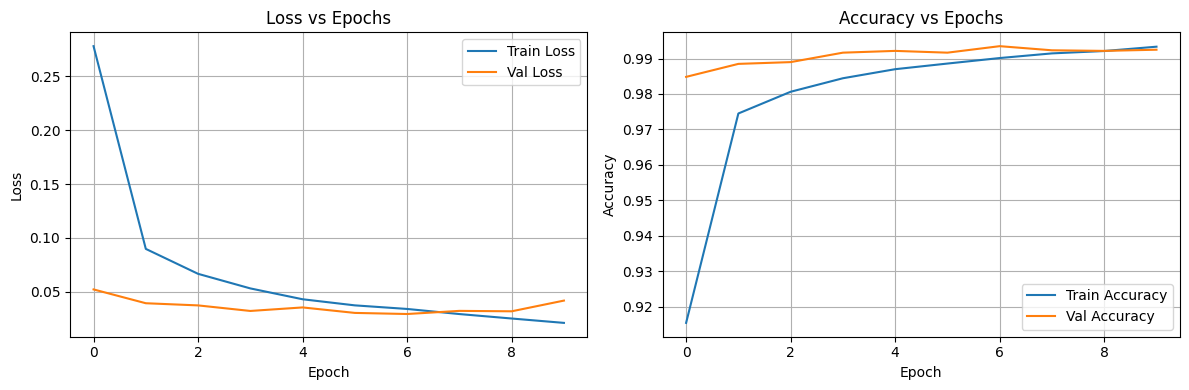

In [ ]:
# Step 7: Plot Training History
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# loss plot: should decrease over epochs
axes[0].plot(history.history['loss'], label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].set_title('Loss vs Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

# accuracy plot: should increase over epochs
axes[1].plot(history.history['accuracy'], label='Train Accuracy')
axes[1].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[1].set_title('Accuracy vs Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [ ]:
# Step 8: Evaluate on Test Set
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f"Test Loss = {test_loss:.4f}")
print(f"Test Accuracy = {test_acc * 100:.2f}%")

Test Loss = 0.0277
Test Accuracy = 99.27%


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 592ms/step


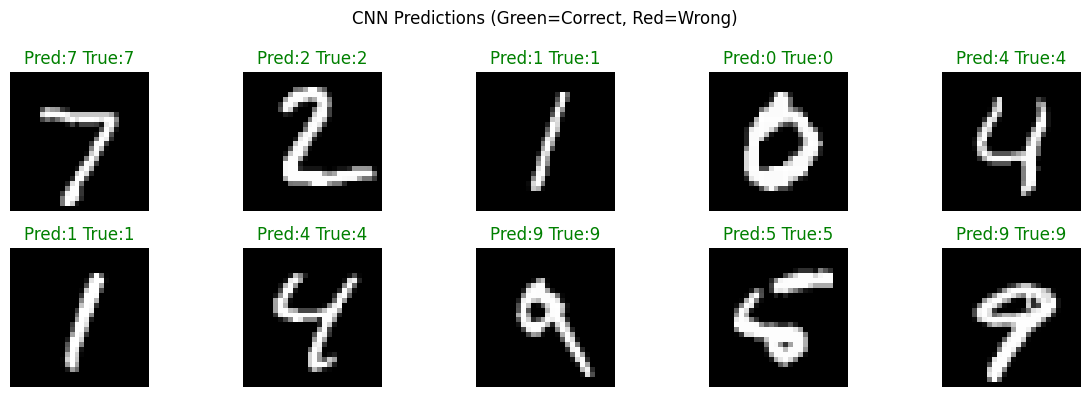

In [ ]:
# Step 9: Visualize Predictions
# get predicted class probabilities for first 10 test images
preds = model.predict(x_test[:10])

# argmax gives the class with highest probability
pred_labels = np.argmax(preds, axis=1)

plt.figure(figsize=(12, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_test[i].squeeze(), cmap='gray')
    color = 'green' if pred_labels[i] == y_test[i] else 'red'
    plt.title(f'Pred:{pred_labels[i]} True:{y_test[i]}', color=color)
    plt.axis('off')

plt.suptitle('CNN Predictions (Green=Correct, Red=Wrong)')
plt.tight_layout()
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step


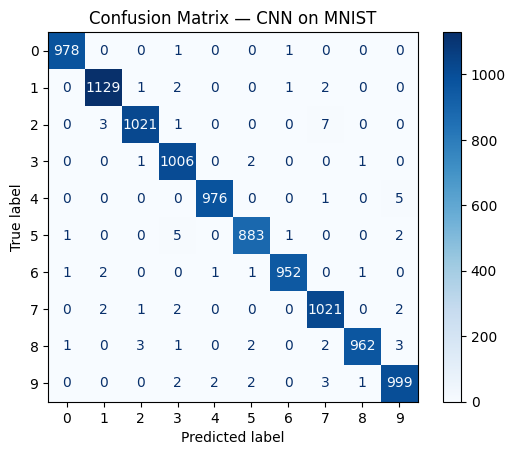

In [ ]:
# Step 10: Confusion Matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# get all predictions for test set
all_preds = np.argmax(model.predict(x_test), axis=1)

# compute confusion matrix
cm = confusion_matrix(y_test, all_preds)

# display as heatmap
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(range(10)))
disp.plot(cmap='Blues')
plt.title('Confusion Matrix — CNN on MNIST')
plt.show()

### CNN FROM SCRATCH

=== Experiment 8: CNN FROM SCRATCH (Manual Convolution Demo) ===
  Input: (28, 28)  →  After Conv: (28, 28)  →  After Pool: (14, 14)


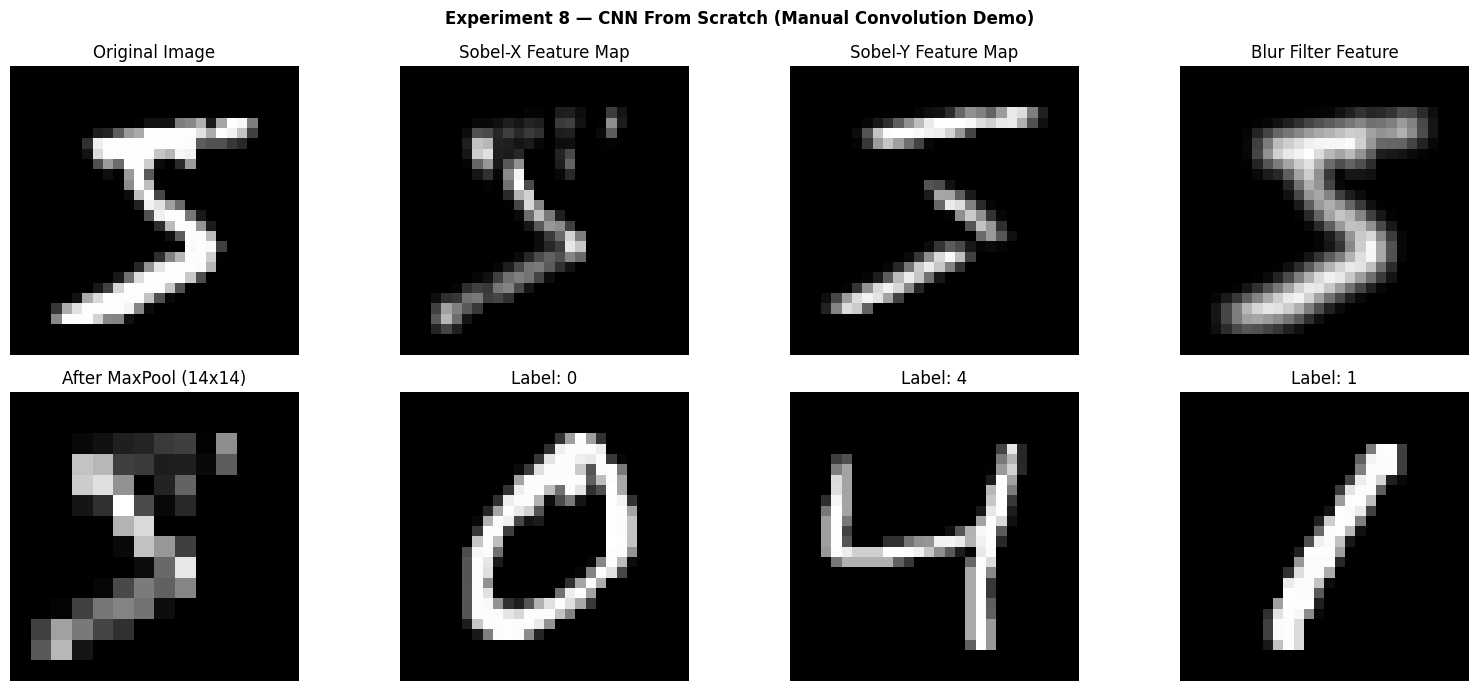

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

print("=== Experiment 8: CNN FROM SCRATCH (Manual Convolution Demo) ===")

np.random.seed(42)

def conv2d_scratch(img, kernel, stride=1, padding=0):
    """Manual 2D convolution on a single-channel image."""
    if padding > 0:
        img = np.pad(img, padding)
    H, W  = img.shape
    kH, kW = kernel.shape
    oH = (H - kH) // stride + 1
    oW = (W - kW) // stride + 1
    out = np.zeros((oH, oW))
    for r in range(oH):
        for c in range(oW):
            out[r, c] = np.sum(img[r*stride:r*stride+kH,
                                   c*stride:c*stride+kW] * kernel)
    return out

def maxpool2x2_fn(feat):
    H, W = feat.shape
    out = np.zeros((H//2, W//2))
    for r in range(H//2):
        for c in range(W//2):
            out[r,c] = feat[2*r:2*r+2, 2*c:2*c+2].max()
    return out

def relu_fn(z): return np.maximum(0, z)

# Load one MNIST image for demo
import tensorflow as tf
(x_train_cnn, y_train_cnn), (x_test_cnn, y_test_cnn) = tf.keras.datasets.mnist.load_data()

sample = x_train_cnn[0].astype(np.float64) / 255.0   # 28x28

# Sobel-X filter as a learnable edge detector example
K_sobel_x = np.array([[-1,0,1],[-2,0,2],[-1,0,1]], dtype=np.float64)
K_sobel_y = np.array([[-1,-2,-1],[0,0,0],[1,2,1]], dtype=np.float64)
K_blur     = np.ones((3,3))/9

feat_edge_x = relu_fn(conv2d_scratch(sample, K_sobel_x, padding=1))
feat_edge_y = relu_fn(conv2d_scratch(sample, K_sobel_y, padding=1))
feat_blur   = relu_fn(conv2d_scratch(sample, K_blur,    padding=1))
feat_pool   = maxpool2x2_fn(feat_edge_x)   # 14x14

print(f"  Input: {sample.shape}  →  After Conv: {feat_edge_x.shape}  →  After Pool: {feat_pool.shape}")

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
fig.suptitle("Experiment 8 — CNN From Scratch (Manual Convolution Demo)", fontweight='bold')
axes[0,0].imshow(sample, cmap='gray');      axes[0,0].set_title("Original Image")
axes[0,1].imshow(feat_edge_x, cmap='gray'); axes[0,1].set_title("Sobel-X Feature Map")
axes[0,2].imshow(feat_edge_y, cmap='gray'); axes[0,2].set_title("Sobel-Y Feature Map")
axes[0,3].imshow(feat_blur, cmap='gray');   axes[0,3].set_title("Blur Filter Feature")
axes[1,0].imshow(feat_pool, cmap='gray');   axes[1,0].set_title("After MaxPool (14x14)")

# Show 3 more random samples
for i, ax in enumerate(axes[1, 1:]):
    ax.imshow(x_train_cnn[i+1], cmap='gray')
    ax.set_title(f"Label: {y_train_cnn[i+1]}")
for ax in axes.ravel(): ax.axis('off')
plt.tight_layout()
plt.show()

# Experiment No 9: - Isolated Random Forest Analyse and identify patterns in data to predict and take action in biological images and data to analyse DNA, RNA, and nuclei patterns to study evolution and identify patterns in gene or cell expression data to uncover new biomarkers.

**Theory:**

1. Isolation Forest is an unsupervised anomaly detection algorithm
2. It works by randomly selecting a feature and a split value to isolate data points
3. Anomalous points (outliers) are easier to isolate — they need fewer splits
4. Normal points are harder to isolate — they need more splits
5. Anomaly Score: shorter path length = more anomalous
6. In biology: anomalies = mutated genes, cancer cells, unusual biomarkers

In [ ]:
# Install and Import Libraries
# numpy: for numerical operations and array handling
import numpy as np

# pandas: for loading and manipulating tabular biological data
import pandas as pd

# matplotlib and seaborn: for plotting graphs and heatmaps
import matplotlib.pyplot as plt
import seaborn as sns

# IsolationForest: the main anomaly detection algorithm we are using
from sklearn.ensemble import IsolationForest

# StandardScaler: normalizes features to same scale before training
from sklearn.preprocessing import StandardScaler

# PCA: reduces high-dimensional data to 2D for visualization
from sklearn.decomposition import PCA

# RandomForestClassifier: supervised version for biomarker classification
from sklearn.ensemble import RandomForestClassifier

# for splitting data into train and test sets
from sklearn.model_selection import train_test_split

# for evaluating the classification model
from sklearn.metrics import classification_report, confusion_matrix

# fix random seed so results are same every time
np.random.seed(42)

print("All libraries imported successfully!")

All libraries imported successfully!


In [ ]:
# Generate Synthetic Biological Dataset (Gene Expression Data)

# we simulate RNA-seq gene expression data
# in real labs, this would come from sequencing machines

# number of biological samples (e.g., tissue samples from patients)
n_samples = 300

# number of genes measured per sample (gene expression features)
n_genes = 10

# --- Normal Samples (healthy cells) ---
# gene expression values follow a normal distribution
# mean=5 and std=1 simulates typical gene activity in healthy tissue
normal_samples = np.random.normal(loc=5, scale=1, size=(n_samples, n_genes))

# --- Anomalous Samples (mutated / cancerous cells) ---
# anomalies have unusual gene expression — very high or low values
# mean=12 simulates overexpressed genes (common in cancer)
n_anomalies = 30
anomalous_samples = np.random.normal(loc=12, scale=2, size=(n_anomalies, n_genes))

# combine normal and anomalous samples into one dataset
X = np.vstack([normal_samples, anomalous_samples])

# create labels: 1 = normal (healthy), -1 = anomaly (mutated/cancer)
# this is used later for visualization and supervised learning
labels_true = np.array([1]*n_samples + [-1]*n_anomalies)

# create gene names for the DataFrame columns
gene_names = [f'Gene_{i+1}' for i in range(n_genes)]

# create a Pandas DataFrame with gene names as column headers
df = pd.DataFrame(X, columns=gene_names)

# add the true label column
df['Label'] = labels_true

print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nClass distribution:")
print(df['Label'].value_counts())

Dataset shape: (330, 11)

First 5 rows:
     Gene_1    Gene_2    Gene_3    Gene_4    Gene_5    Gene_6    Gene_7  \
0  5.496714  4.861736  5.647689  6.523030  4.765847  4.765863  6.579213   
1  4.536582  4.534270  5.241962  3.086720  3.275082  4.437712  3.987169   
2  6.465649  4.774224  5.067528  3.575252  4.455617  5.110923  3.849006   
3  4.398293  6.852278  4.986503  3.942289  5.822545  3.779156  5.208864   
4  5.738467  5.171368  4.884352  4.698896  3.521478  4.280156  4.539361   

     Gene_8    Gene_9   Gene_10  Label  
0  5.767435  4.530526  5.542560      1  
1  5.314247  4.091976  3.587696      1  
2  5.375698  4.399361  4.708306      1  
3  3.040330  3.671814  5.196861      1  
4  6.057122  5.343618  3.236960      1  

Class distribution:
Label
 1    300
-1     30
Name: count, dtype: int64


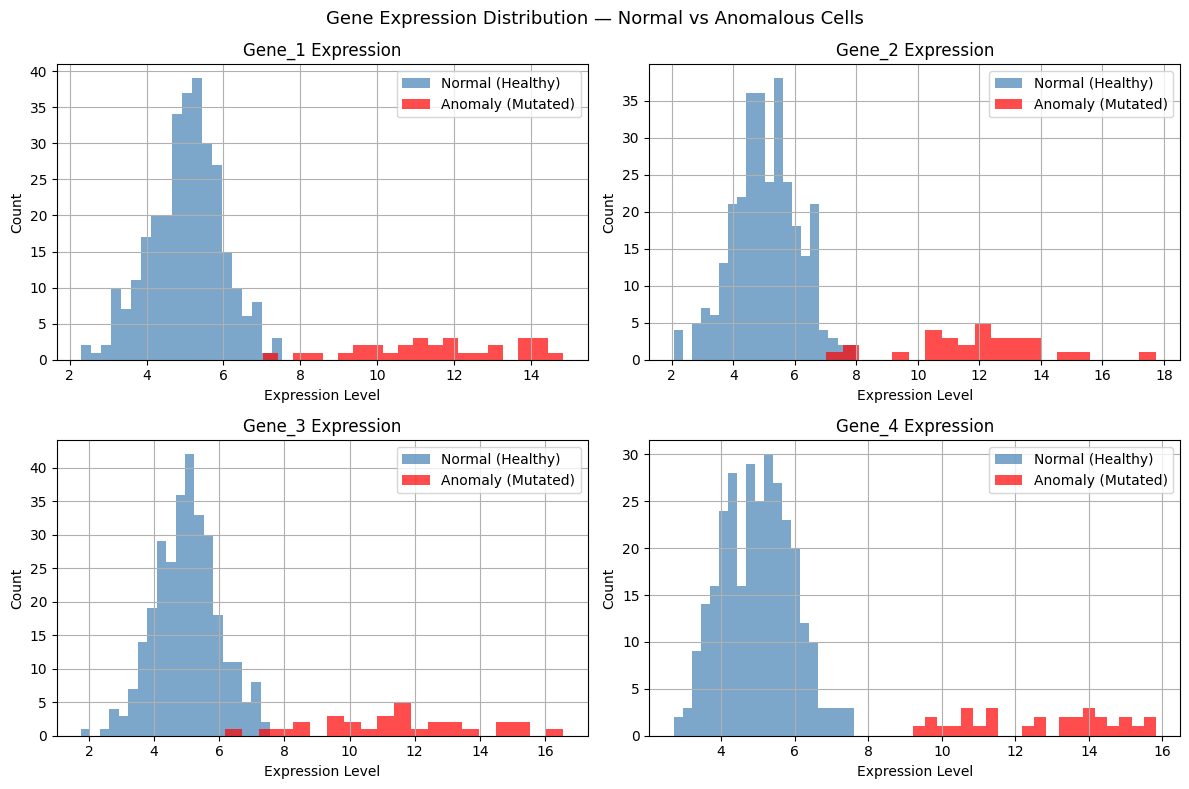

In [ ]:
# Explore the Data — Gene Expression Distribution

# plot gene expression distribution for first 4 genes
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()   # flatten 2x2 grid to a list for easy looping

for i in range(4):
    # plot distribution for normal samples (blue)
    axes[i].hist(df[df['Label']==1][gene_names[i]],
                 bins=20, color='steelblue', alpha=0.7, label='Normal (Healthy)')
    # plot distribution for anomalous samples (red)
    axes[i].hist(df[df['Label']==-1][gene_names[i]],
                 bins=20, color='red', alpha=0.7, label='Anomaly (Mutated)')
    axes[i].set_title(f'{gene_names[i]} Expression')
    axes[i].set_xlabel('Expression Level')
    axes[i].set_ylabel('Count')
    axes[i].legend()
    axes[i].grid(True)

plt.suptitle('Gene Expression Distribution — Normal vs Anomalous Cells', fontsize=13)
plt.tight_layout()
plt.show()

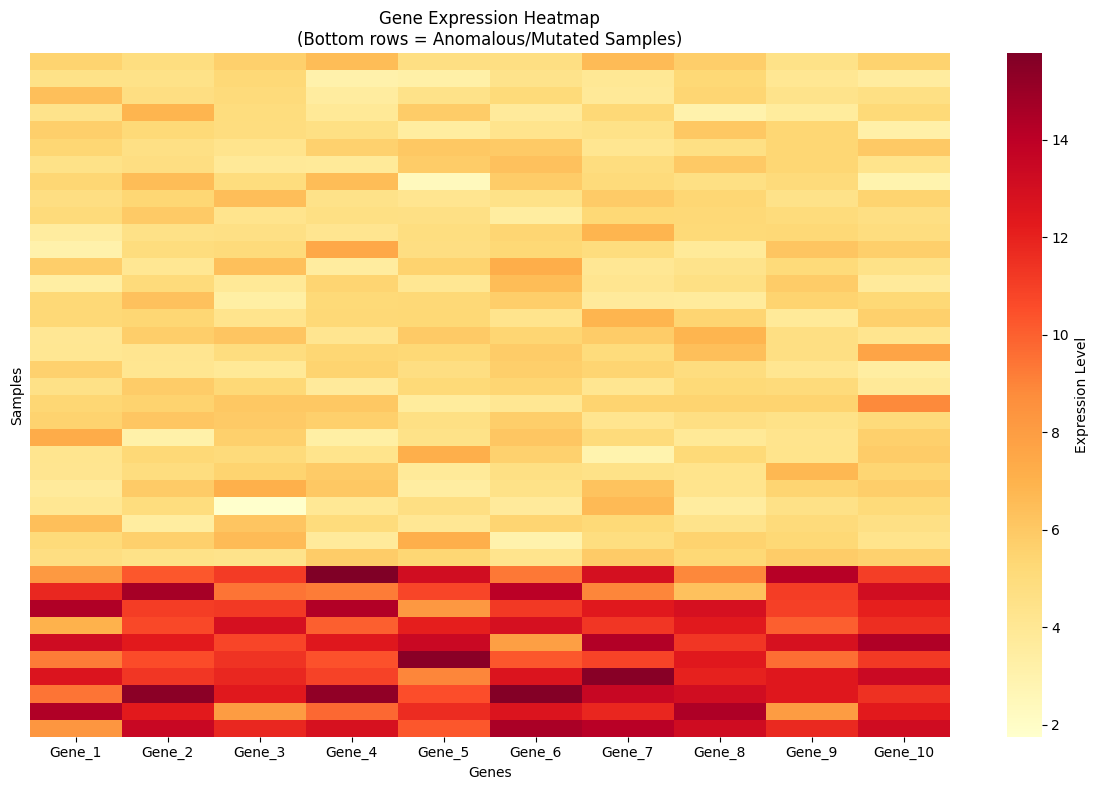

In [ ]:
# Heatmap of Gene Expression (like in real RNA-seq analysis)

# heatmap shows expression level of all genes across selected samples
# rows = samples, columns = genes
# color intensity shows how high or low each gene is expressed

# select 30 normal + 10 anomalous samples for the heatmap
heatmap_data = pd.concat([
    df[df['Label']==1].head(30),
    df[df['Label']==-1].head(10)
])

# extract only gene expression columns (drop label)
heatmap_values = heatmap_data[gene_names]

plt.figure(figsize=(12, 8))
sns.heatmap(
    heatmap_values,
    cmap='YlOrRd',          # yellow=low expression, red=high expression
    yticklabels=False,       # hide sample row labels (too many)
    cbar_kws={'label': 'Expression Level'}
)
plt.title('Gene Expression Heatmap\n(Bottom rows = Anomalous/Mutated Samples)')
plt.xlabel('Genes')
plt.ylabel('Samples')
plt.tight_layout()
plt.show()

In [ ]:
# Normalize the Data

# extract feature matrix (all gene expression columns)
X_features = df[gene_names].values

# StandardScaler normalizes each gene to have mean=0 and std=1
# this ensures no single gene dominates just because of scale
scaler = StandardScaler()

# fit_transform: compute mean/std and apply normalization in one step
X_scaled = scaler.fit_transform(X_features)

print("Before scaling — mean:", X_features.mean().round(2), "std:", X_features.std().round(2))
print("After  scaling — mean:", X_scaled.mean().round(2),   "std:", X_scaled.std().round(2))

Before scaling — mean: 5.66 std: 2.27
After  scaling — mean: 0.0 std: 1.0


In [ ]:
# Apply Isolation Forest

# Isolation Forest model
# n_estimators=100: build 100 isolation trees
# contamination=0.09: we expect about 9% of samples to be anomalies
#   (30 anomalies out of 330 total = ~9%)
# random_state=42: for reproducibility
iso_forest = IsolationForest(
    n_estimators=100,
    contamination=0.09,
    random_state=42
)

# fit the model on the scaled data
# Isolation Forest learns what 'normal' looks like
iso_forest.fit(X_scaled)

# predict: returns 1 (normal) or -1 (anomaly) for each sample
predictions = iso_forest.predict(X_scaled)

# decision_function: gives anomaly score for each sample
# more negative score = more anomalous
anomaly_scores = iso_forest.decision_function(X_scaled)

print("Predictions (first 20):", predictions[:20])
print("Predictions (last 10 — anomalies):", predictions[-10:])
print("\nNumber of detected anomalies:", np.sum(predictions == -1))
print("Number of detected normal:   ", np.sum(predictions == 1))

Predictions (first 20): [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
Predictions (last 10 — anomalies): [-1 -1 -1 -1 -1 -1 -1 -1 -1 -1]

Number of detected anomalies: 30
Number of detected normal:    300


Anomaly Detection Accuracy: 100.00%


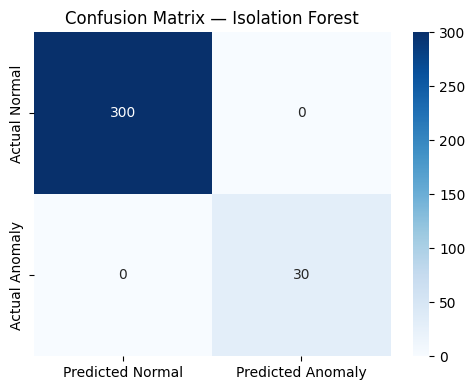

In [ ]:
# Evaluate Detection Accuracy

# compare predicted labels with true labels
correct = np.sum(predictions == labels_true)
total   = len(labels_true)
accuracy = correct / total * 100

print(f"Anomaly Detection Accuracy: {accuracy:.2f}%")

# confusion matrix: rows=actual, columns=predicted
cm = confusion_matrix(labels_true, predictions, labels=[1, -1])

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,              # show numbers inside cells
    fmt='d',                 # integer format
    cmap='Blues',
    xticklabels=['Predicted Normal', 'Predicted Anomaly'],
    yticklabels=['Actual Normal', 'Actual Anomaly']
)
plt.title('Confusion Matrix — Isolation Forest')
plt.tight_layout()
plt.show()

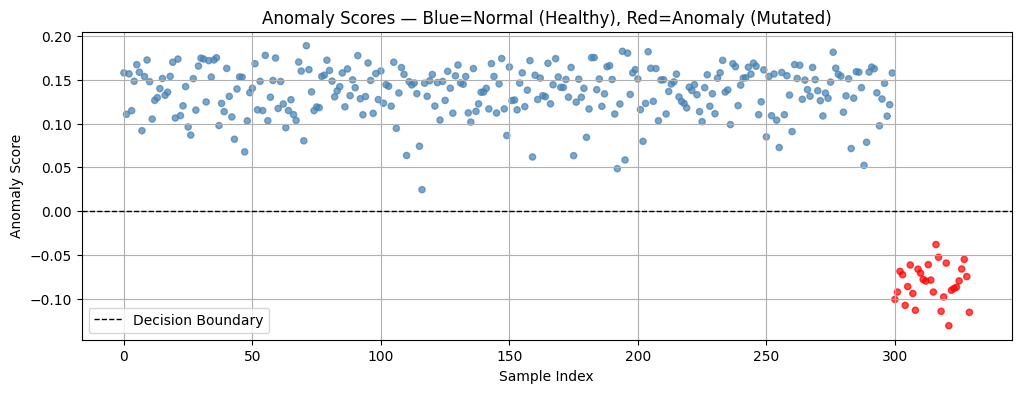

Samples below the 0 line are flagged as anomalies (potential cancer/mutation).


In [ ]:
# Visualize Anomaly Scores

# plot anomaly scores for all samples
# lower (more negative) scores = more anomalous
plt.figure(figsize=(12, 4))

# color each point based on true label
colors = ['red' if l == -1 else 'steelblue' for l in labels_true]

plt.scatter(range(len(anomaly_scores)), anomaly_scores, c=colors, s=20, alpha=0.7)
plt.axhline(0, color='black', linestyle='--', linewidth=1, label='Decision Boundary')
plt.xlabel('Sample Index')
plt.ylabel('Anomaly Score')
plt.title('Anomaly Scores — Blue=Normal (Healthy), Red=Anomaly (Mutated)')
plt.legend()
plt.grid(True)
plt.show()

print("Samples below the 0 line are flagged as anomalies (potential cancer/mutation).")

Variance explained by PC1: 0.779
Variance explained by PC2: 0.032


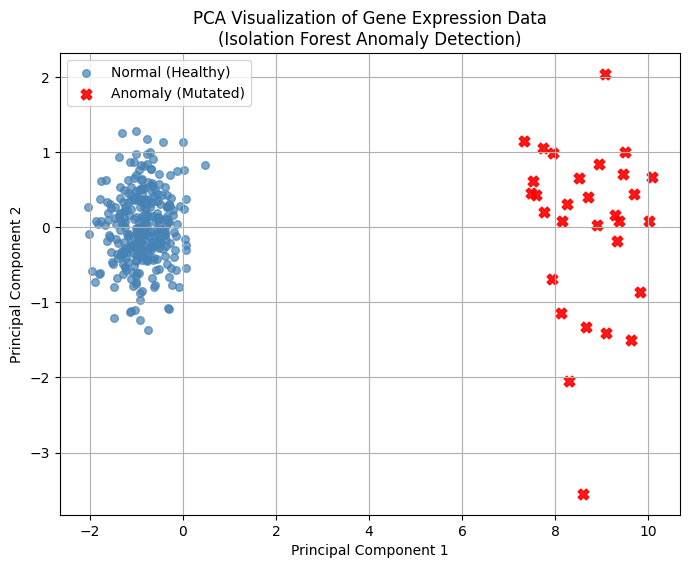

In [ ]:
# PCA Visualization — See Clusters in 2D

# PCA reduces 10 gene dimensions to 2D so we can visualize clusters
# n_components=2: keep only 2 principal components
pca = PCA(n_components=2)

# fit PCA on scaled data and transform it to 2D
X_pca = pca.fit_transform(X_scaled)

# how much variance is explained by each component
print("Variance explained by PC1:", pca.explained_variance_ratio_[0].round(3))
print("Variance explained by PC2:", pca.explained_variance_ratio_[1].round(3))

# plot PCA with true labels
plt.figure(figsize=(8, 6))

# plot normal samples in blue
normal_mask = labels_true == 1
plt.scatter(X_pca[normal_mask, 0], X_pca[normal_mask, 1],
            c='steelblue', s=30, label='Normal (Healthy)', alpha=0.7)

# plot anomalous samples in red
anomaly_mask = labels_true == -1
plt.scatter(X_pca[anomaly_mask, 0], X_pca[anomaly_mask, 1],
            c='red', s=60, marker='X', label='Anomaly (Mutated)', alpha=0.9)

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA Visualization of Gene Expression Data\n(Isolation Forest Anomaly Detection)')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Random Forest — Biomarker Identification

# now we use supervised Random Forest to identify WHICH genes
# are the most important biomarkers (features that best separate
# normal vs anomalous/cancerous samples)

# convert labels from -1/1 to 0/1 for sklearn
# 0 = anomaly (mutated), 1 = normal (healthy)
y_binary = (labels_true == 1).astype(int)

# split into 80% training and 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_binary, test_size=0.2, random_state=42
)

# build Random Forest classifier
# n_estimators=100: use 100 decision trees
# random_state=42: reproducibility
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# train the model
rf_model.fit(X_train, y_train)

# predict on test set
y_pred = rf_model.predict(X_test)

# print classification report
print("=== Random Forest Classification Report ===")
print(classification_report(y_test, y_pred, target_names=['Anomaly', 'Normal']))

=== Random Forest Classification Report ===
              precision    recall  f1-score   support

     Anomaly       1.00      1.00      1.00         7
      Normal       1.00      1.00      1.00        59

    accuracy                           1.00        66
   macro avg       1.00      1.00      1.00        66
weighted avg       1.00      1.00      1.00        66



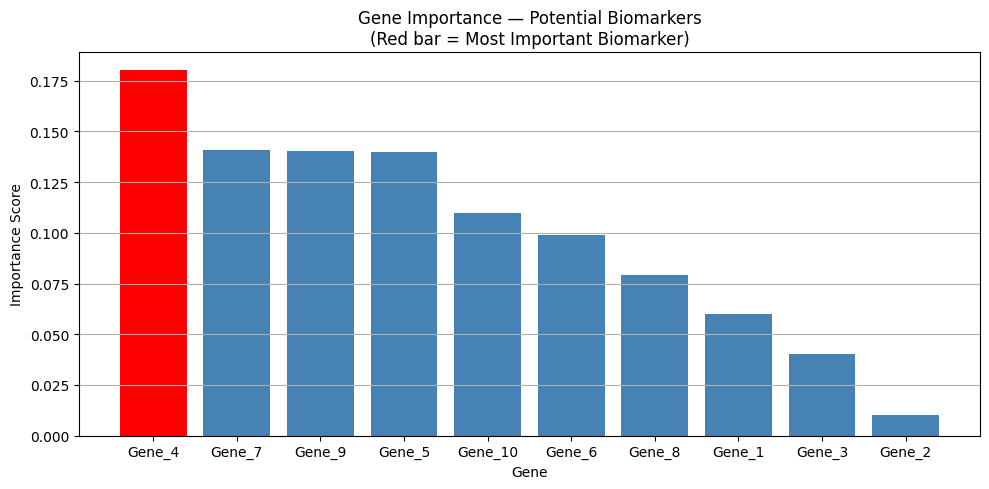


Top 3 Biomarker Genes:
  1. Gene_4 — Importance: 0.1800
  2. Gene_7 — Importance: 0.1406
  3. Gene_9 — Importance: 0.1404


In [ ]:
# Feature Importance — Which Genes are Biomarkers?

# feature_importances_ gives a score for each gene
# higher score = gene is more important for classification
# these important genes = potential BIOMARKERS
importances = rf_model.feature_importances_

# sort genes by importance (descending)
sorted_idx = np.argsort(importances)[::-1]
sorted_genes = [gene_names[i] for i in sorted_idx]
sorted_importance = importances[sorted_idx]

# plot feature importance
plt.figure(figsize=(10, 5))
colors_bar = ['red' if i == 0 else 'steelblue' for i in range(len(sorted_genes))]
plt.bar(sorted_genes, sorted_importance, color=colors_bar)
plt.xlabel('Gene')
plt.ylabel('Importance Score')
plt.title('Gene Importance — Potential Biomarkers\n(Red bar = Most Important Biomarker)')
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()

print("\nTop 3 Biomarker Genes:")
for i in range(3):
    print(f"  {i+1}. {sorted_genes[i]} — Importance: {sorted_importance[i]:.4f}")

In [ ]:
# Summary

print("=" * 50)
print("   EXPERIMENT 9 — SUMMARY")
print("=" * 50)
print(f"  Total samples analysed   : {len(X)}")
print(f"  Normal (healthy) samples : {n_samples}")
print(f"  Anomalous (mutated) cells: {n_anomalies}")
print(f"  Genes (features) measured: {n_genes}")
print(f"  Isolation Forest detected: {np.sum(predictions == -1)} anomalies")
print(f"  Detection Accuracy       : {accuracy:.2f}%")
print(f"  Top Biomarker Gene       : {sorted_genes[0]}")
print("=" * 50)
print("\nConclusion:")
print("Isolation Forest successfully detected mutated/anomalous")
print("cell samples from gene expression data. Random Forest")
print("further identified the most important biomarker genes")
print("that distinguish healthy from cancerous samples.")

   EXPERIMENT 9 — SUMMARY
  Total samples analysed   : 330
  Normal (healthy) samples : 300
  Anomalous (mutated) cells: 30
  Genes (features) measured: 10
  Isolation Forest detected: 30 anomalies
  Detection Accuracy       : 100.00%
  Top Biomarker Gene       : Gene_4

Conclusion:
Isolation Forest successfully detected mutated/anomalous
cell samples from gene expression data. Random Forest
further identified the most important biomarker genes
that distinguish healthy from cancerous samples.


### Anomaly Detection from Scratch

=== Experiment 9: Anomaly Detection FROM SCRATCH ===
  Dataset: 200 normal + 20 anomalous samples, 4 genes
  Scratch Isolation Forest Accuracy = 98.18%


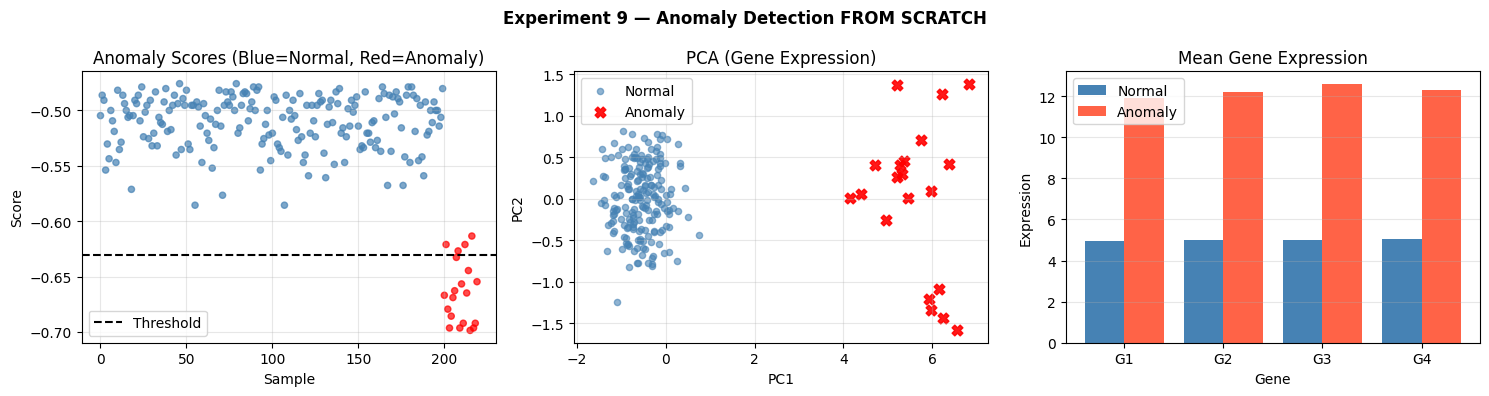

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

print("=== Experiment 9: Anomaly Detection FROM SCRATCH ===")

# Synthetic gene expression dataset
n_normal, n_anomaly, n_genes = 200, 20, 4
X_normal  = np.random.normal(loc=5, scale=1,   size=(n_normal,  n_genes))
X_anomaly = np.random.normal(loc=12, scale=2,  size=(n_anomaly, n_genes))
X_all     = np.vstack([X_normal, X_anomaly])
y_true    = np.array([1]*n_normal + [-1]*n_anomaly)  # 1=normal, -1=anomaly

print(f"  Dataset: {n_normal} normal + {n_anomaly} anomalous samples, {n_genes} genes")

# Normalise
mu_g, sg_g = X_all.mean(axis=0), X_all.std(axis=0)
X_scaled   = (X_all - mu_g) / sg_g

# ── Isolation Forest from Scratch ──
class IsolationTreeScratch:
    """Single isolation tree node."""
    def __init__(self):
        self.feature = None; self.split = None
        self.left = None;    self.right = None
        self.depth = None

def build_tree(X, depth=0, max_depth=8):
    node = IsolationTreeScratch()
    node.depth = depth
    if len(X) <= 1 or depth >= max_depth:
        return node
    node.feature = np.random.randint(X.shape[1])
    mn, mx = X[:, node.feature].min(), X[:, node.feature].max()
    if mn == mx:
        return node
    node.split = np.random.uniform(mn, mx)
    left_mask  = X[:, node.feature] < node.split
    node.left  = build_tree(X[left_mask],  depth+1, max_depth)
    node.right = build_tree(X[~left_mask], depth+1, max_depth)
    return node

def path_length(node, x, depth=0):
    if node.feature is None or node.left is None:
        return depth
    if x[node.feature] < node.split:
        return path_length(node.left, x, depth+1)
    return path_length(node.right, x, depth+1)

def average_path_length(n):
    """Expected path length in a BST with n samples."""
    if n <= 1: return 0
    return 2 * (np.log(n-1) + 0.5772) - 2*(n-1)/n

# Build a small forest
n_trees = 30
trees = [build_tree(X_scaled[np.random.choice(len(X_scaled), 64, replace=False)])
         for _ in range(n_trees)]

raw_scores = np.array([[path_length(t, x) for t in trees] for x in X_scaled]).mean(axis=1)
c_n = average_path_length(64)
anomaly_scores = -2**(- raw_scores / c_n)   # negative = anomaly

threshold = np.percentile(anomaly_scores, 7)  # bottom 7% are anomalies
predictions = np.where(anomaly_scores < threshold, -1, 1)

accuracy_scratch = np.mean(predictions == y_true) * 100
print(f"  Scratch Isolation Forest Accuracy = {accuracy_scratch:.2f}%")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Experiment 9 — Anomaly Detection FROM SCRATCH", fontweight='bold')

colors_anom = ['red' if l==-1 else 'steelblue' for l in y_true]
axes[0].scatter(range(len(anomaly_scores)), anomaly_scores, c=colors_anom, s=20, alpha=0.7)
axes[0].axhline(threshold, color='black', linestyle='--', lw=1.5, label='Threshold')
axes[0].set(title='Anomaly Scores (Blue=Normal, Red=Anomaly)', xlabel='Sample', ylabel='Score')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

from sklearn.decomposition import PCA
pca_scratch = PCA(n_components=2)
X_pca_s = pca_scratch.fit_transform(X_scaled)
axes[1].scatter(X_pca_s[y_true==1,0],  X_pca_s[y_true==1,1],  c='steelblue', s=20, alpha=0.6, label='Normal')
axes[1].scatter(X_pca_s[y_true==-1,0], X_pca_s[y_true==-1,1], c='red',  s=60, marker='X', alpha=0.9, label='Anomaly')
axes[1].set(title='PCA (Gene Expression)', xlabel='PC1', ylabel='PC2')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

gene_means_normal  = X_all[y_true==1].mean(axis=0)
gene_means_anomaly = X_all[y_true==-1].mean(axis=0)
x_axis = np.arange(n_genes)
axes[2].bar(x_axis - 0.2, gene_means_normal,  0.4, label='Normal',  color='steelblue')
axes[2].bar(x_axis + 0.2, gene_means_anomaly, 0.4, label='Anomaly', color='tomato')
axes[2].set(title='Mean Gene Expression', xlabel='Gene', ylabel='Expression')
axes[2].set_xticks(x_axis); axes[2].set_xticklabels([f'G{i+1}' for i in range(n_genes)])
axes[2].legend(); axes[2].grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# Experiment No 10: - Neural network for Pattern and hand Movement Recognition.

**Theory:**

1. A Neural Network has an input layer, hidden layers, and an output layer
2. **Each neuron computes:** output = activation(weights · inputs + bias)
3. **ReLU activation:** f(x) = max(0, x) — used in hidden layers
4. **Softmax activation:** converts scores to probabilities — used in output layer
5. **Backpropagation:** calculates gradients and updates weights to reduce loss
6. **Dropout:** randomly disables neurons during training to prevent overfitting

In [ ]:
# Import Libraries

# numpy: for all array and numerical operations
import numpy as np

# pandas: for creating and handling the dataset as a table
import pandas as pd

# matplotlib and seaborn: for plotting graphs and confusion matrix
import matplotlib.pyplot as plt
import seaborn as sns

# tensorflow and keras: for building the neural network
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# sklearn tools: for splitting data and evaluating performance
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report

# fix random seed so we get same results every run
np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow version:", tf.__version__)
print("All libraries imported!")

TensorFlow version: 2.20.0
All libraries imported!


In [ ]:
# Generate Synthetic Hand Movement Dataset

# define gesture class names
# each class represents one type of hand movement
gesture_names = ['Rest', 'Swipe_Left', 'Swipe_Right', 'Swipe_Up', 'Swipe_Down']
n_classes = len(gesture_names)   # 5 classes

# number of samples per gesture class
samples_per_class = 200

# each sample has 6 sensor features:
# accel_x, accel_y, accel_z = accelerometer readings (measures acceleration)
# gyro_x,  gyro_y,  gyro_z  = gyroscope readings (measures rotation)
feature_names = ['accel_x', 'accel_y', 'accel_z', 'gyro_x', 'gyro_y', 'gyro_z']

all_data   = []   # list to store all feature rows
all_labels = []   # list to store all labels

# generate data for each gesture class with unique patterns
for class_id in range(n_classes):

    # each gesture has a unique mean vector that represents its typical movement
    # e.g., Swipe Left has high negative accel_x, Swipe Right has high positive accel_x
    mean_vector = np.zeros(6)

    if class_id == 0:   # Rest — all values near zero (no movement)
        mean_vector = [0, 0, 9.8, 0, 0, 0]        # only gravity (9.8) on z-axis

    elif class_id == 1: # Swipe Left — strong negative x acceleration
        mean_vector = [-8, 0, 9.8, 0, 0, -3]

    elif class_id == 2: # Swipe Right — strong positive x acceleration
        mean_vector = [8, 0, 9.8, 0, 0, 3]

    elif class_id == 3: # Swipe Up — strong positive y acceleration
        mean_vector = [0, 8, 9.8, -3, 0, 0]

    elif class_id == 4: # Swipe Down — strong negative y acceleration
        mean_vector = [0, -8, 9.8, 3, 0, 0]

    # generate samples by adding Gaussian noise to the mean vector
    # scale=1.5 means std deviation of noise = 1.5 (realistic sensor variation)
    samples = np.random.normal(
        loc=mean_vector,
        scale=1.5,
        size=(samples_per_class, 6)
    )

    all_data.append(samples)
    all_labels.extend([class_id] * samples_per_class)

# stack all class data into one matrix
X = np.vstack(all_data)          # shape: (1000, 6)
y = np.array(all_labels)         # shape: (1000,)

# create a Pandas DataFrame for easy viewing
df = pd.DataFrame(X, columns=feature_names)
df['gesture'] = [gesture_names[i] for i in y]

print("Dataset shape:", df.shape)
print("\nSample rows:")
print(df.head(10))
print("\nGesture distribution:")
print(df['gesture'].value_counts())

Dataset shape: (1000, 7)

Sample rows:
    accel_x   accel_y    accel_z    gyro_x    gyro_y    gyro_z gesture
0  0.745071 -0.207396  10.771533  2.284545 -0.351230 -0.351205    Rest
1  2.368819  1.151152   9.095788  0.813840 -0.695127 -0.698595    Rest
2  0.362943 -2.869920   7.212623 -0.843431 -1.519247  0.471371    Rest
3 -1.362036 -2.118456  11.998473 -0.338664  0.101292 -2.137122    Rest
4 -0.816574  0.166384   8.073510  0.563547 -0.900958 -0.437541    Rest
5 -0.902560  2.778417   9.779754 -1.586566  1.233817 -1.831265    Rest
6  0.313295 -2.939505   7.807721  0.295292  1.107700  0.257052    Rest
7 -0.173472 -0.451656   7.582217 -1.079766 -0.690958  1.585683    Rest
8  0.515427 -2.644560  10.286126 -0.577623 -1.015383  0.917514    Rest
9  1.546499  1.396920   8.541174 -0.463819  0.496895  1.463318    Rest

Gesture distribution:
gesture
Rest           200
Swipe_Left     200
Swipe_Right    200
Swipe_Up       200
Swipe_Down     200
Name: count, dtype: int64


/tmp/ipykernel_3051/2784954124.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot(gesture_groups_x, labels=gesture_names, patch_artist=True)
/tmp/ipykernel_3051/2784954124.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(gesture_groups_y, labels=gesture_names, patch_artist=True)


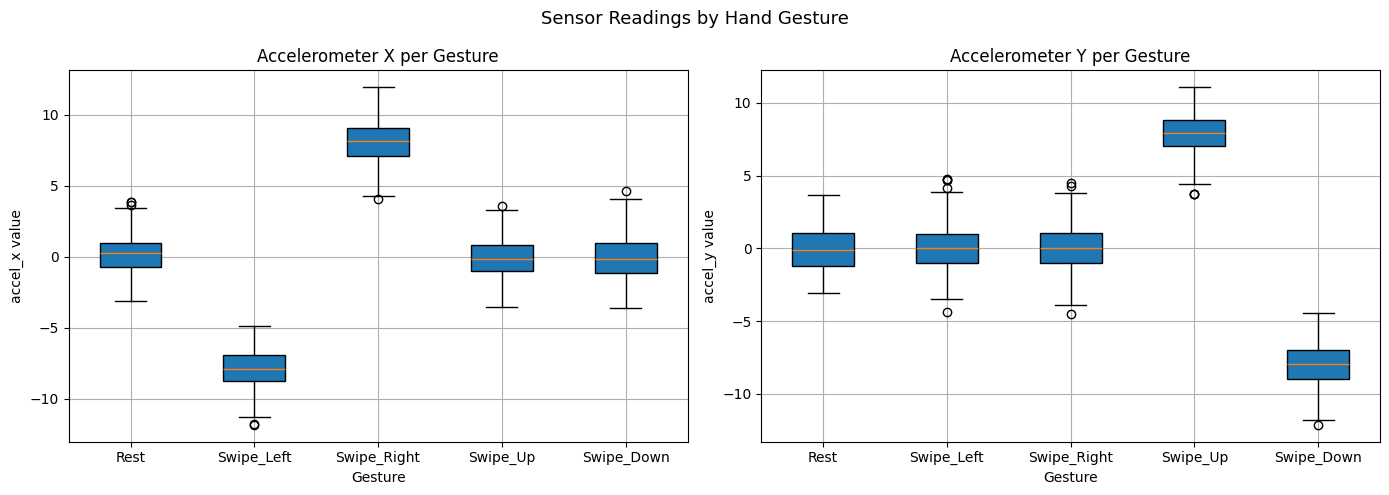

In [ ]:
# Visualize Sensor Data for Each Gesture

# box plot comparing accel_x and accel_y distributions across gesture classes
# this shows how different gestures have different acceleration signatures
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# accel_x for each gesture
gesture_groups_x = [df[df['gesture'] == g]['accel_x'].values for g in gesture_names]
axes[0].boxplot(gesture_groups_x, labels=gesture_names, patch_artist=True)
axes[0].set_title('Accelerometer X per Gesture')
axes[0].set_xlabel('Gesture')
axes[0].set_ylabel('accel_x value')
axes[0].grid(True)

# accel_y for each gesture
gesture_groups_y = [df[df['gesture'] == g]['accel_y'].values for g in gesture_names]
axes[1].boxplot(gesture_groups_y, labels=gesture_names, patch_artist=True)
axes[1].set_title('Accelerometer Y per Gesture')
axes[1].set_xlabel('Gesture')
axes[1].set_ylabel('accel_y value')
axes[1].grid(True)

plt.suptitle('Sensor Readings by Hand Gesture', fontsize=13)
plt.tight_layout()
plt.show()

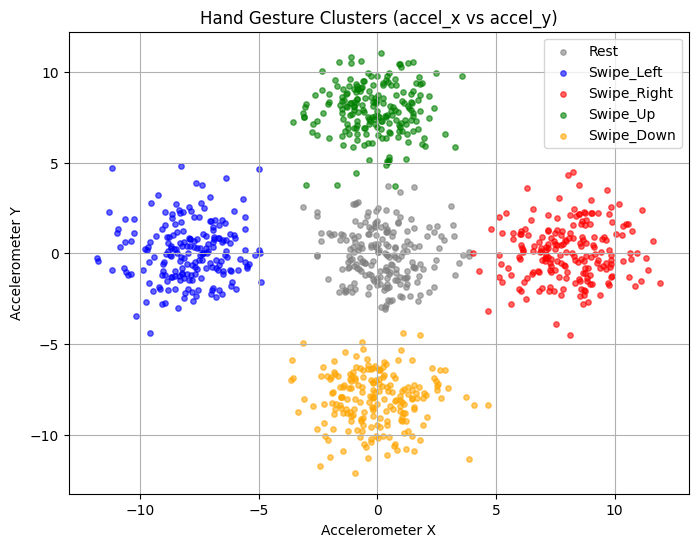

In [ ]:
# scatter plot: accel_x vs accel_y — shows how gestures separate in 2D
colors = ['gray', 'blue', 'red', 'green', 'orange']

plt.figure(figsize=(8, 6))
for i, gesture in enumerate(gesture_names):
    mask = df['gesture'] == gesture
    plt.scatter(
        df[mask]['accel_x'],
        df[mask]['accel_y'],
        c=colors[i], label=gesture, s=15, alpha=0.6
    )
plt.xlabel('Accelerometer X')
plt.ylabel('Accelerometer Y')
plt.title('Hand Gesture Clusters (accel_x vs accel_y)')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Preprocess Data

# extract features and labels
X_features = df[feature_names].values   # shape: (1000, 6)
y_labels   = y                          # integer labels 0-4

# normalize features using StandardScaler
# makes each feature have mean=0 and std=1
# helps neural network train faster and more stably
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_features)

# convert integer labels to one-hot encoding
# e.g., class 2 → [0, 0, 1, 0, 0]
# required for categorical_crossentropy loss
y_onehot = keras.utils.to_categorical(y_labels, num_classes=n_classes)

print("X_scaled shape:", X_scaled.shape)
print("y_onehot shape:", y_onehot.shape)
print("\nExample label (class 2 = Swipe_Right):", y_onehot[400])

X_scaled shape: (1000, 6)
y_onehot shape: (1000, 5)

Example label (class 2 = Swipe_Right): [0. 0. 1. 0. 0.]


In [ ]:
# split dataset into training (70%), validation (15%), and test (15%)
# training set: used to train the model
# validation set: used to monitor overfitting during training
# test set: used for final evaluation

X_train, X_temp, y_train, y_temp = train_test_split(
    X_scaled, y_onehot, test_size=0.3, random_state=42, stratify=y_labels
)

# split the remaining 30% into validation and test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

print(f"Training samples  : {len(X_train)}")
print(f"Validation samples: {len(X_val)}")
print(f"Test samples      : {len(X_test)}")

Training samples  : 700
Validation samples: 150
Test samples      : 150


In [ ]:
# Build the Neural Network

# build a multi-layer neural network using Keras Sequential API
model = keras.Sequential([

    # Input layer: accepts 6 sensor features
    keras.Input(shape=(6,)),

    # First hidden layer: 128 neurons with ReLU activation
    # Dense = fully connected (every neuron connected to all inputs)
    # ReLU: f(x) = max(0, x) — removes negatives, adds non-linearity
    layers.Dense(128, activation='relu'),

    # Batch Normalization: normalizes activations within each mini-batch
    # makes training faster and more stable
    layers.BatchNormalization(),

    # Dropout: randomly sets 30% of neurons to 0 during training
    # prevents overfitting by forcing the network to not rely on any single neuron
    layers.Dropout(0.3),

    # Second hidden layer: 64 neurons with ReLU
    layers.Dense(64, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    # Third hidden layer: 32 neurons
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.2),

    # Output layer: 5 neurons = 5 gesture classes
    # Softmax: converts raw scores to probabilities that sum to 1
    # e.g., [0.05, 0.03, 0.80, 0.07, 0.05] → predicted class = 2 (Swipe Right)
    layers.Dense(n_classes, activation='softmax')
])

# print model architecture summary
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 128)            │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 5)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,165 (47.52 KB)

 Trainable params: 11,781 (46.02 KB)

 Non-trainable params: 384 (1.50 KB)

In [ ]:
# Compile the Model

# compile the model with optimizer, loss function, and metric
model.compile(
    # Adam optimizer: adaptive learning rate — good default for neural networks
    optimizer=keras.optimizers.Adam(learning_rate=0.001),

    # categorical_crossentropy: used when labels are one-hot encoded
    # measures how wrong the predicted probability distribution is
    loss='categorical_crossentropy',

    # accuracy: proportion of correctly classified samples
    metrics=['accuracy']
)

print("Model compiled successfully!")

Model compiled successfully!


In [ ]:
# Train the Neural Network

# EarlyStopping: stops training if validation loss doesn't improve
# monitor='val_loss': watches validation loss
# patience=10: stop after 10 epochs with no improvement
# restore_best_weights=True: revert to best weights after stopping
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

# train the model
# epochs=100: maximum 100 training iterations
# batch_size=32: update weights after every 32 samples
# validation_data: evaluate on val set after every epoch
history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=[early_stop],
    verbose=1
)

print(f"\nTraining stopped at epoch: {len(history.history['loss'])}")

Epoch 1/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 10s 195ms/step - accuracy: 0.4714 - loss: 1.3625 - val_accuracy: 0.8400 - val_loss: 1.2605
Epoch 2/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7614 - loss: 0.6461 - val_accuracy: 0.9333 - val_loss: 0.9795
Epoch 3/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8514 - loss: 0.4380 - val_accuracy: 0.9600 - val_loss: 0.7443
Epoch 4/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8843 - loss: 0.3407 - val_accuracy: 0.9267 - val_loss: 0.5775
Epoch 5/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9457 - loss: 0.2329 - val_accuracy: 0.9267 - val_loss: 0.4470
Epoch 6/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9386 - loss: 0.2146 - val_accuracy: 0.9333 - val_loss: 0.3445
Epoch 7/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9629 - loss: 0.1437 - val_accuracy: 0.9333 - val_loss: 0.2805
Epoch 8/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9543 - loss: 0.1502 - val_accuracy: 0.9533 

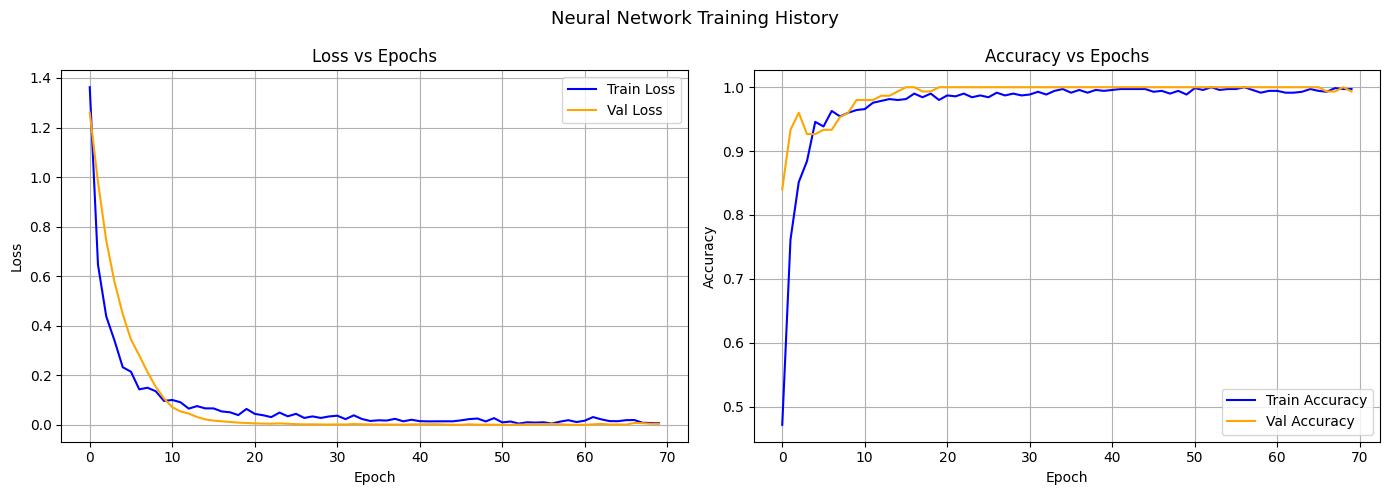

In [ ]:
# Plot Training History

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# plot training and validation loss
# loss should decrease as model learns
axes[0].plot(history.history['loss'],     label='Train Loss',     color='blue')
axes[0].plot(history.history['val_loss'], label='Val Loss',       color='orange')
axes[0].set_title('Loss vs Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

# plot training and validation accuracy
# accuracy should increase as model learns
axes[1].plot(history.history['accuracy'],     label='Train Accuracy', color='blue')
axes[1].plot(history.history['val_accuracy'], label='Val Accuracy',   color='orange')
axes[1].set_title('Accuracy vs Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.suptitle('Neural Network Training History', fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
# Evaluate on Test Set

# evaluate the trained model on the test set
# test set was never seen during training — gives unbiased accuracy
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss     = {test_loss:.4f}")
print(f"Test Accuracy = {test_acc * 100:.2f}%")

Test Loss     = 0.0006
Test Accuracy = 100.00%


In [ ]:
# Confusion Matrix and Classification Report

# get predicted class probabilities for test set
y_pred_probs = model.predict(X_test)

# argmax gives index of highest probability = predicted class
y_pred_classes = np.argmax(y_pred_probs, axis=1)

# convert one-hot true labels back to integers
y_true_classes = np.argmax(y_test, axis=1)

# classification report: precision, recall, f1-score per class
print("=== Classification Report ===")
print(classification_report(
    y_true_classes,
    y_pred_classes,
    target_names=gesture_names
))

In [ ]:
# confusion matrix: shows which gestures are confused with each other
# diagonal = correct predictions
# off-diagonal = misclassifications
cm = confusion_matrix(y_true_classes, y_pred_classes)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,          # show count numbers inside cells
    fmt='d',             # integer format
    cmap='Blues',
    xticklabels=gesture_names,
    yticklabels=gesture_names
)
plt.xlabel('Predicted Gesture')
plt.ylabel('Actual Gesture')
plt.title('Confusion Matrix — Hand Gesture Recognition')
plt.tight_layout()
plt.show()

In [ ]:
# Test with a Single Sample

# simulate a new sensor reading for 'Swipe Right' gesture
# accel_x=8 (strong positive x movement), accel_y=0, accel_z=9.8 (gravity)
new_sample = np.array([[8.2, 0.3, 9.7, 0.1, 0.2, 3.1]])

# normalize using the same scaler fitted on training data
new_sample_scaled = scaler.transform(new_sample)

# predict: get probability for each gesture class
prediction_probs = model.predict(new_sample_scaled)

# the class with the highest probability is our prediction
predicted_class = np.argmax(prediction_probs)
predicted_gesture = gesture_names[predicted_class]

print("=== Single Sample Prediction ===")
print(f"Sensor Input: accel_x=8.2, accel_y=0.3, accel_z=9.7, gyro_x=0.1, gyro_y=0.2, gyro_z=3.1")
print(f"\nPrediction Probabilities:")
for i, (name, prob) in enumerate(zip(gesture_names, prediction_probs[0])):
    bar = '█' * int(prob * 30)   # simple ASCII bar
    print(f"  {name:15s}: {prob:.4f}  {bar}")
print(f"\n→ Predicted Gesture: {predicted_gesture}")

In [ ]:
# Summary

print("=" * 52)
print("   EXPERIMENT 10 — SUMMARY")
print("=" * 52)
print(f"  Total samples         : {len(X_scaled)}")
print(f"  Gesture classes       : {n_classes} ({', '.join(gesture_names)})")
print(f"  Sensor features       : {len(feature_names)} (accel + gyro)")
print(f"  Neural Network layers : Input → 128 → 64 → 32 → Output")
print(f"  Epochs trained        : {len(history.history['loss'])}")
print(f"  Test Accuracy         : {test_acc * 100:.2f}%")
print("=" * 52)
print("\nConclusion:")
print("The Neural Network successfully learned to classify")
print("hand movement gestures from accelerometer and gyroscope")
print("sensor data. ReLU activations, Batch Normalization,")
print("and Dropout helped the model generalize well.")

=== Experiment 10: Hand Gesture NN FROM SCRATCH ===
  Scratch NN Test Accuracy = 82.50%


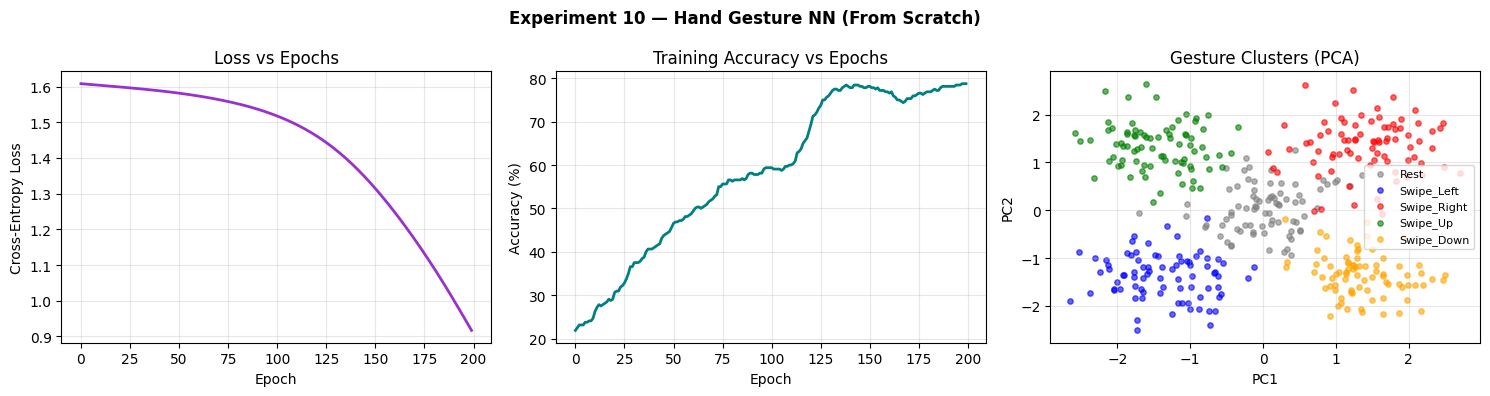

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

print("=== Experiment 10: Hand Gesture NN FROM SCRATCH ===")

# Generate synthetic accelerometer + gyroscope data
gesture_names = ['Rest', 'Swipe_Left', 'Swipe_Right', 'Swipe_Up', 'Swipe_Down']
n_classes = 5;  samples_per = 80;  n_features = 6
means = [
    [0, 0, 9.8, 0, 0, 0],      # Rest
    [-8, 0, 9.8, 0, 0, -3],    # Swipe Left
    [8,  0, 9.8, 0, 0,  3],    # Swipe Right
    [0,  8, 9.8, -3, 0, 0],    # Swipe Up
    [0, -8, 9.8,  3, 0, 0],    # Swipe Down
]
X_all = np.vstack([np.random.normal(m, 1.5, (samples_per, n_features)) for m in means])
y_all = np.array([c for c in range(n_classes) for _ in range(samples_per)])

# Normalise
mu_h = X_all.mean(axis=0);  sg_h = X_all.std(axis=0)
X_norm = (X_all - mu_h) / sg_h

# One-hot
def one_hot_fn(labels, n):
    oh = np.zeros((len(labels), n))
    oh[np.arange(len(labels)), labels] = 1
    return oh

Y_oh = one_hot_fn(y_all, n_classes)

# Train-test split (80/20)
np.random.seed(0)
idx = np.random.permutation(len(X_norm))
split = int(0.8 * len(idx))
Xtr_s, Xte_s = X_norm[idx[:split]], X_norm[idx[split:]]
Ytr_s, Yte_s = Y_oh[idx[:split]],   Y_oh[idx[split:]]
yte_int = y_all[idx[split:]]

# Network architecture: 6 → 32 → 16 → 5
def relu_fn(z): return np.maximum(0, z)
def relu_grad_fn(z): return (z > 0).astype(float)
def softmax_fn(z):
    e = np.exp(z - z.max(axis=1, keepdims=True))
    return e / e.sum(axis=1, keepdims=True)
def ce_loss(yp, yt): return -np.sum(yt * np.log(yp+1e-9)) / len(yp)

np.random.seed(7)
W1_h = np.random.randn(6, 32) * 0.1;  b1_h = np.zeros((1,32))
W2_h = np.random.randn(32, 16) * 0.1; b2_h = np.zeros((1,16))
W3_h = np.random.randn(16, 5) * 0.1;  b3_h = np.zeros((1,5))

lr_h = 0.05; loss_curve_h = []; acc_curve_h = []

for epoch in range(200):
    # Forward pass (3 layers)
    Z1h = Xtr_s @ W1_h + b1_h;  A1h = relu_fn(Z1h)
    Z2h = A1h @ W2_h + b2_h;    A2h = relu_fn(Z2h)
    Z3h = A2h @ W3_h + b3_h;    A3h = softmax_fn(Z3h)

    loss_curve_h.append(ce_loss(A3h, Ytr_s))
    preds_epoch = np.argmax(A3h, axis=1)
    acc_curve_h.append(np.mean(preds_epoch == np.argmax(Ytr_s, axis=1)))

    # Backprop
    dZ3 = A3h - Ytr_s
    dW3 = A2h.T @ dZ3 / len(Xtr_s);  db3 = dZ3.mean(axis=0, keepdims=True)
    dA2 = dZ3 @ W3_h.T
    dZ2 = dA2 * relu_grad_fn(Z2h)
    dW2 = A1h.T @ dZ2 / len(Xtr_s);  db2 = dZ2.mean(axis=0, keepdims=True)
    dA1 = dZ2 @ W2_h.T
    dZ1 = dA1 * relu_grad_fn(Z1h)
    dW1 = Xtr_s.T @ dZ1 / len(Xtr_s); db1 = dZ1.mean(axis=0, keepdims=True)

    W3_h -= lr_h*dW3;  b3_h -= lr_h*db3
    W2_h -= lr_h*dW2;  b2_h -= lr_h*db2
    W1_h -= lr_h*dW1;  b1_h -= lr_h*db1

# Test accuracy
Z1t = Xte_s @ W1_h + b1_h;  A1t = relu_fn(Z1t)
Z2t = A1t @ W2_h + b2_h;    A2t = relu_fn(Z2t)
Z3t = A2t @ W3_h + b3_h;    A3t = softmax_fn(Z3t)
test_acc_scratch = np.mean(np.argmax(A3t, axis=1) == yte_int) * 100
print(f"  Scratch NN Test Accuracy = {test_acc_scratch:.2f}%")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Experiment 10 — Hand Gesture NN (From Scratch)", fontweight='bold')

axes[0].plot(loss_curve_h, color='darkorchid', lw=2)
axes[0].set(title='Loss vs Epochs', xlabel='Epoch', ylabel='Cross-Entropy Loss')
axes[0].grid(True, alpha=0.3)

axes[1].plot([a*100 for a in acc_curve_h], color='teal', lw=2)
axes[1].set(title='Training Accuracy vs Epochs', xlabel='Epoch', ylabel='Accuracy (%)')
axes[1].grid(True, alpha=0.3)

from sklearn.decomposition import PCA as PCA_h
pca_h = PCA_h(n_components=2)
X_pca_h = pca_h.fit_transform(X_norm)
colors_h = ['gray','blue','red','green','orange']
for i, g in enumerate(gesture_names):
    mask = y_all == i
    axes[2].scatter(X_pca_h[mask,0], X_pca_h[mask,1], c=colors_h[i], s=15, label=g, alpha=0.6)
axes[2].set(title='Gesture Clusters (PCA)', xlabel='PC1', ylabel='PC2')
axes[2].legend(fontsize=8); axes[2].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()